# Step 5: Fine-Tune and Evaluate
## Horizon-Aware Startup Outcome Prediction

## 5.0 Setup and Load Trained Models

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib
import torch
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, balanced_accuracy_score, f1_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as LR_calibrator

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from src.evaluation import ResultsCollector, compute_all_metrics, expected_calibration_error
from src.models import (
    identify_column_types, prepare_catboost_data,
    build_lr_preprocessor, build_hgb_preprocessor,
    TabMPreprocessor, TabMWrapper,
)

# ── Plotting defaults ─────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0', '#00BCD4']
FIG_DIR = Path('../figures')
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')

SEED = 42
np.random.seed(SEED)

# ── Load data splits ──────────────────────────────────────────────
def load_split(horizon, split):
    X = pd.read_csv(DATA_DIR / f"{horizon}_{split}_X.csv")
    y = pd.read_csv(DATA_DIR / f"{horizon}_{split}_y.csv").squeeze()
    return X, y

splits = {}
for h in ["H1", "H2", "H3"]:
    splits[h] = {}
    for s in ["train", "val", "test"]:
        X, y = load_split(h, s)
        splits[h][s] = (X, y)

# ── Cap time_to_first_funding_days (same as Phase 4) ──────────────
for h in ["H2", "H3"]:
    col = 'time_to_first_funding_days'
    if col in splits[h]['train'][0].columns:
        cap = splits[h]['train'][0][col].quantile(0.99)
        for s in ["train", "val", "test"]:
            X, y = splits[h][s]
            X[col] = X[col].clip(upper=cap)

# ── Load trained models ──────────────────────────────────────────
models = {}

# sklearn/catboost models (joblib)
for fpath in sorted(MODEL_DIR.glob('*.joblib')):
    key = fpath.stem  # e.g. "H1_CatBoost"
    models[key] = joblib.load(fpath)
    print(f"Loaded: {key}")

# TabM models (torch)
with open(MODEL_DIR / 'best_params.json') as f:
    best_params = json.load(f)

for fpath in sorted(MODEL_DIR.glob('*.pt')):
    key = fpath.stem  # e.g. "H1_TabM"
    checkpoint = torch.load(fpath, map_location='cpu', weights_only=False)
    prep = checkpoint['preprocessor']
    horizon = key.split('_')[0]
    params = best_params.get(key, {})

    from tabm import TabM as TabMModel
    n_num = len(prep.num_cols_)
    cat_cards = prep.cat_cardinalities_ if prep.cat_cols_ else None
    tabm_model = TabMModel(
        n_num_features=n_num,
        cat_cardinalities=cat_cards,
        d_out=1,
        k=params.get('k', 32),
        n_blocks=params.get('n_blocks', 2),
        d_block=params.get('d_block', 128),
        dropout=params.get('dropout', 0.1),
        arch_type="tabm",
        start_scaling_init="random-signs",
    )
    tabm_model.load_state_dict(checkpoint['model_state'])
    tabm_model.eval()
    wrapper = TabMWrapper(tabm_model, prep)
    models[key] = wrapper
    print(f"Loaded: {key}")

# ── Load Phase 4 results ─────────────────────────────────────────
results_df = pd.read_csv(DATA_DIR / 'modelling_results.csv')
print(f"\nLoaded {len(results_df)} result rows from Phase 4")

print(f"\nModels loaded: {sorted(models.keys())}")
print("Setup complete.")


Loaded: H1_CatBoost


Loaded: H1_HistGradientBoosting
Loaded: H1_LogisticRegression
Loaded: H2_CatBoost
Loaded: H2_HistGradientBoosting
Loaded: H2_LogisticRegression
Loaded: H3_CatBoost
Loaded: H3_LogisticRegression
Loaded: H1_TabM


Loaded: H2_TabM

Loaded 24 result rows from Phase 4

Models loaded: ['H1_CatBoost', 'H1_HistGradientBoosting', 'H1_LogisticRegression', 'H1_TabM', 'H2_CatBoost', 'H2_HistGradientBoosting', 'H2_LogisticRegression', 'H2_TabM', 'H3_CatBoost', 'H3_LogisticRegression']
Setup complete.


## 5.0.1 Generate Predictions for All Models

Generate predicted probabilities on both validation and test sets for all loaded models. These predictions are used throughout the evaluation.

In [2]:
# ── Generate predictions for all models on val and test ───────────
predictions = {}  # (horizon, model_name, split) -> y_prob array

MODEL_NAMES = {
    'LogisticRegression': 'LR',
    'HistGradientBoosting': 'HGB',
    'CatBoost': 'CB',
    'TabM': 'TabM',
}

for key, model in models.items():
    parts = key.split('_', 1)
    horizon = parts[0]
    model_name = parts[1]

    for split in ['val', 'test']:
        X, y = splits[horizon][split]

        if model_name == 'CatBoost':
            X_prep, _ = prepare_catboost_data(X)
            y_prob = model.predict_proba(X_prep)[:, 1]
        elif model_name == 'TabM':
            y_prob = model.predict_proba(X)[:, 1]
        else:
            y_prob = model.predict_proba(X)[:, 1]

        predictions[(horizon, model_name, split)] = y_prob
        auc = roc_auc_score(y, y_prob)
        short = MODEL_NAMES.get(model_name, model_name)
        print(f"{horizon} {short:4s} {split}: AUC={auc:.4f}")

print(f"\nTotal prediction sets: {len(predictions)}")


H1 CB   val: AUC=0.7021
H1 CB   test: AUC=0.6739


H1 HGB  val: AUC=0.6762


H1 HGB  test: AUC=0.6589
H1 LR   val: AUC=0.6799
H1 LR   test: AUC=0.6650
H2 CB   val: AUC=0.7111
H2 CB   test: AUC=0.6995


H2 HGB  val: AUC=0.6848
H2 HGB  test: AUC=0.6708
H2 LR   val: AUC=0.6737
H2 LR   test: AUC=0.6401
H3 CB   val: AUC=0.7783


H3 CB   test: AUC=0.7700
H3 LR   val: AUC=0.7422
H3 LR   test: AUC=0.6831


H1 TabM val: AUC=0.6962


H1 TabM test: AUC=0.6677


H2 TabM val: AUC=0.6913


H2 TabM test: AUC=0.6741

Total prediction sets: 20


## 5.1 Hyperparameter Tuning Summary

Phase 4 used Optuna (TPE sampler) for hyperparameter optimisation across all models and horizons. Below are the search spaces and best parameters found.

**Tuning protocol:**
- **LogisticRegression:** 20 Optuna trials per horizon. Search space: C ∈ [10⁻⁴, 10], penalty ∈ {l1, l2, elasticnet}, l1_ratio ∈ [0.1, 0.9]
- **HistGradientBoosting:** 25 trials per horizon. Search space: learning_rate ∈ [0.01, 0.3], max_depth ∈ [3, 10], max_leaf_nodes ∈ [15, 63], min_samples_leaf ∈ [10, 50], l2_regularization ∈ [0, 5], max_iter ∈ [100, 500]. Internal early stopping (patience=15)
- **CatBoost:** 30 trials (H1/H2), 20 trials (H3). Search space: iterations ∈ [100, 500], depth ∈ [3, 8], learning_rate ∈ [0.01, 0.3], l2_leaf_reg ∈ [1, 10], random_strength ∈ [0, 3], bagging_temperature ∈ [0, 3]. Validation-based early stopping (patience=30)
- **TabM:** 15 trials per horizon. Search space: k ∈ {8, 16, 32}, n_blocks ∈ [1, 3], d_block ∈ {64, 128, 256}, dropout ∈ [0, 0.3], lr ∈ [10⁻⁴, 10⁻²], weight_decay ∈ [10⁻⁶, 10⁻²], batch_size ∈ {128, 256, 512}. Early stopping on validation AUC (patience=15)

In [3]:
# ── Display best hyperparameters ──────────────────────────────────
print("Best Hyperparameters by Horizon x Model")
print("=" * 60)
for key in sorted(best_params.keys()):
    print(f"\n{key}:")
    for param, val in best_params[key].items():
        if isinstance(val, float):
            print(f"  {param}: {val:.6g}")
        else:
            print(f"  {param}: {val}")


Best Hyperparameters by Horizon x Model

H1_CatBoost:
  iterations: 492
  depth: 6
  learning_rate: 0.282925
  l2_leaf_reg: 9.97612
  random_strength: 2.98741
  bagging_temperature: 2.32716

H1_HistGradientBoosting:
  learning_rate: 0.169675
  max_depth: 4
  max_leaf_nodes: 23
  min_samples_leaf: 17
  l2_regularization: 1.52121
  max_iter: 310

H1_LogisticRegression:
  C: 2.86182
  penalty: l1

H1_TabM:
  k: 8
  n_blocks: 1
  d_block: 256
  dropout: 0.196251
  lr: 0.000107195
  weight_decay: 2.33443e-05
  batch_size: 512

H2_CatBoost:
  iterations: 422
  depth: 6
  learning_rate: 0.150509
  l2_leaf_reg: 9.88068
  random_strength: 2.00942
  bagging_temperature: 0.83992

H2_HistGradientBoosting:
  learning_rate: 0.021659
  max_depth: 5
  max_leaf_nodes: 53
  min_samples_leaf: 42
  l2_regularization: 4.06128
  max_iter: 343

H2_LogisticRegression:
  C: 0.00158994
  penalty: elasticnet
  l1_ratio: 0.118847

H2_TabM:
  k: 32
  n_blocks: 1
  d_block: 256
  dropout: 0.165903
  lr: 0.000376698

## 5.2 Cross-Horizon AUC Comparison (Signature Figure)

**THE centrepiece finding:** How ROC-AUC changes as we move from the most defensible horizon (H1: founding-time) through the practical compromise (H2: first-funding) to the leakiest (H3: full snapshot). The gap between H1 and H3 quantifies the performance inflation caused by using lifetime funding aggregates as features.

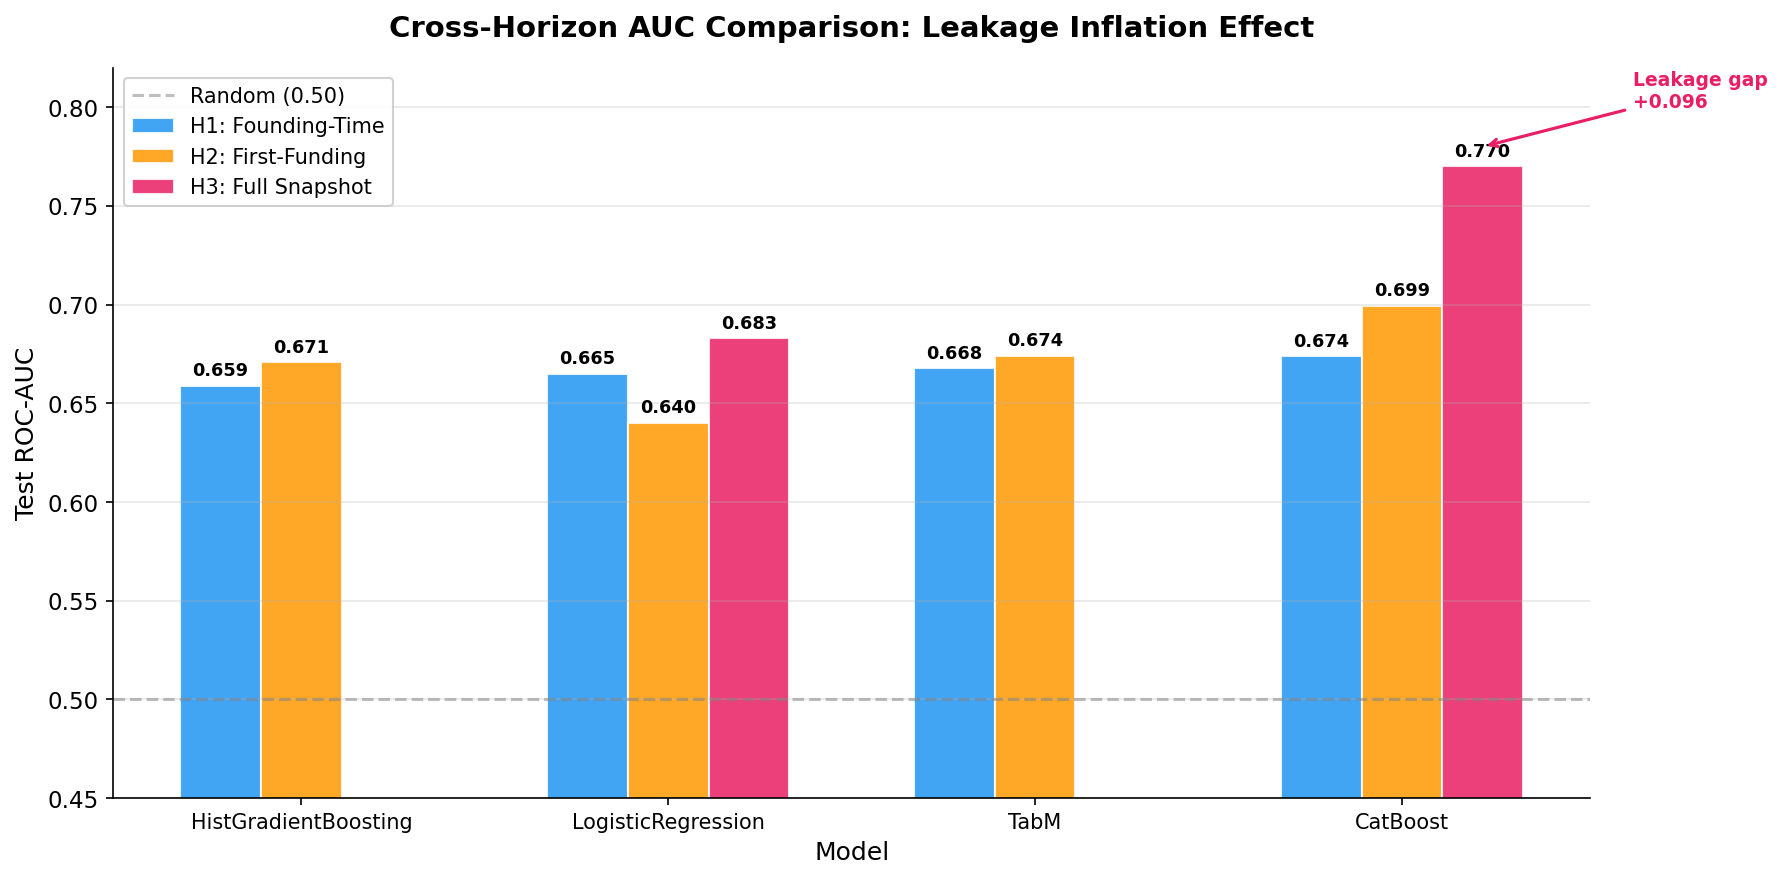

Saved: figures/14_cross_horizon_auc_comparison.png

Leakage Gap Analysis (Test Set):
  LogisticRegression:
    H1=0.6650 -> H2=0.6401 -> H3=0.6831
    H3-H1 gap: +0.0181
    H2-H1 gain: +-0.0248 (first-funding signal)
  CatBoost:
    H1=0.6739 -> H2=0.6995 -> H3=0.7700
    H3-H1 gap: +0.0961
    H2-H1 gain: +0.0256 (first-funding signal)


In [4]:
# ── Build comparison data ─────────────────────────────────────────
# Use test-set AUC for the signature figure (most honest evaluation)
fig_data = []
for (horizon, model_name, split), y_prob in predictions.items():
    if split != 'test':
        continue
    y_true = splits[horizon]['test'][1]
    auc = roc_auc_score(y_true, y_prob)
    fig_data.append({
        'Horizon': horizon,
        'Model': model_name,
        'ROC-AUC': auc,
    })

fig_df = pd.DataFrame(fig_data)

# Order models by H1 performance
model_order_h1 = (fig_df[fig_df['Horizon'] == 'H1']
                  .sort_values('ROC-AUC')['Model'].tolist())
# Add H3-only models
for m in fig_df['Model'].unique():
    if m not in model_order_h1:
        model_order_h1.append(m)

horizon_order = ['H1', 'H2', 'H3']
horizon_labels = {
    'H1': 'H1: Founding-Time',
    'H2': 'H2: First-Funding',
    'H3': 'H3: Full Snapshot',
}
horizon_colors = {'H1': '#2196F3', 'H2': '#FF9800', 'H3': '#E91E63'}

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.22
x_positions = np.arange(len(model_order_h1))

for i, horizon in enumerate(horizon_order):
    h_df = fig_df[fig_df['Horizon'] == horizon]
    aucs = []
    for model in model_order_h1:
        row = h_df[h_df['Model'] == model]
        aucs.append(row['ROC-AUC'].values[0] if len(row) > 0 else 0)

    bars = ax.bar(x_positions + i * bar_width, aucs, bar_width,
                  label=horizon_labels[horizon],
                  color=horizon_colors[horizon], alpha=0.85, edgecolor='white')

    # Add value labels on bars
    for bar, auc in zip(bars, aucs):
        if auc > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                    f'{auc:.3f}', ha='center', va='bottom', fontsize=8.5,
                    fontweight='bold')

# Random baseline
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.50)')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Test ROC-AUC', fontsize=12)
ax.set_title('Cross-Horizon AUC Comparison: Leakage Inflation Effect',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_positions + bar_width)
ax.set_xticklabels(model_order_h1, fontsize=10)
ax.set_ylim(0.45, 0.82)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

# Add leakage gap annotation for CatBoost
cb_h1 = fig_df[(fig_df['Model'] == 'CatBoost') & (fig_df['Horizon'] == 'H1')]['ROC-AUC'].values[0]
cb_h3 = fig_df[(fig_df['Model'] == 'CatBoost') & (fig_df['Horizon'] == 'H3')]['ROC-AUC'].values[0]
gap = cb_h3 - cb_h1
cb_idx = model_order_h1.index('CatBoost')
ax.annotate(f'Leakage gap\n+{gap:.3f}',
            xy=(cb_idx + 2 * bar_width, cb_h3 + 0.01),
            xytext=(cb_idx + 2.5 * bar_width + 0.3, cb_h3 + 0.03),
            fontsize=9, fontweight='bold', color='#E91E63',
            arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1.5),
            ha='left')

plt.tight_layout()
plt.savefig(FIG_DIR / '14_cross_horizon_auc_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: figures/14_cross_horizon_auc_comparison.png")

# ── Print leakage gaps ───────────────────────────────────────────
print("\nLeakage Gap Analysis (Test Set):")
for model in ['LogisticRegression', 'CatBoost']:
    h1_row = fig_df[(fig_df['Model'] == model) & (fig_df['Horizon'] == 'H1')]
    h3_row = fig_df[(fig_df['Model'] == model) & (fig_df['Horizon'] == 'H3')]
    if not h1_row.empty and not h3_row.empty:
        h1_auc = h1_row['ROC-AUC'].values[0]
        h2_row = fig_df[(fig_df['Model'] == model) & (fig_df['Horizon'] == 'H2')]
        h2_auc = h2_row['ROC-AUC'].values[0] if not h2_row.empty else None
        h3_auc = h3_row['ROC-AUC'].values[0]
        print(f"  {model}:")
        print(f"    H1={h1_auc:.4f} -> H2={h2_auc:.4f} -> H3={h3_auc:.4f}")
        print(f"    H3-H1 gap: +{h3_auc - h1_auc:.4f}")
        if h2_auc:
            print(f"    H2-H1 gain: +{h2_auc - h1_auc:.4f} (first-funding signal)")


## 5.3 ROC Curves — All Models on H1

ROC curves for all models on the H1 (founding-time) test set. This is the most defensible horizon — the cleanest causal prediction with no temporal contamination.

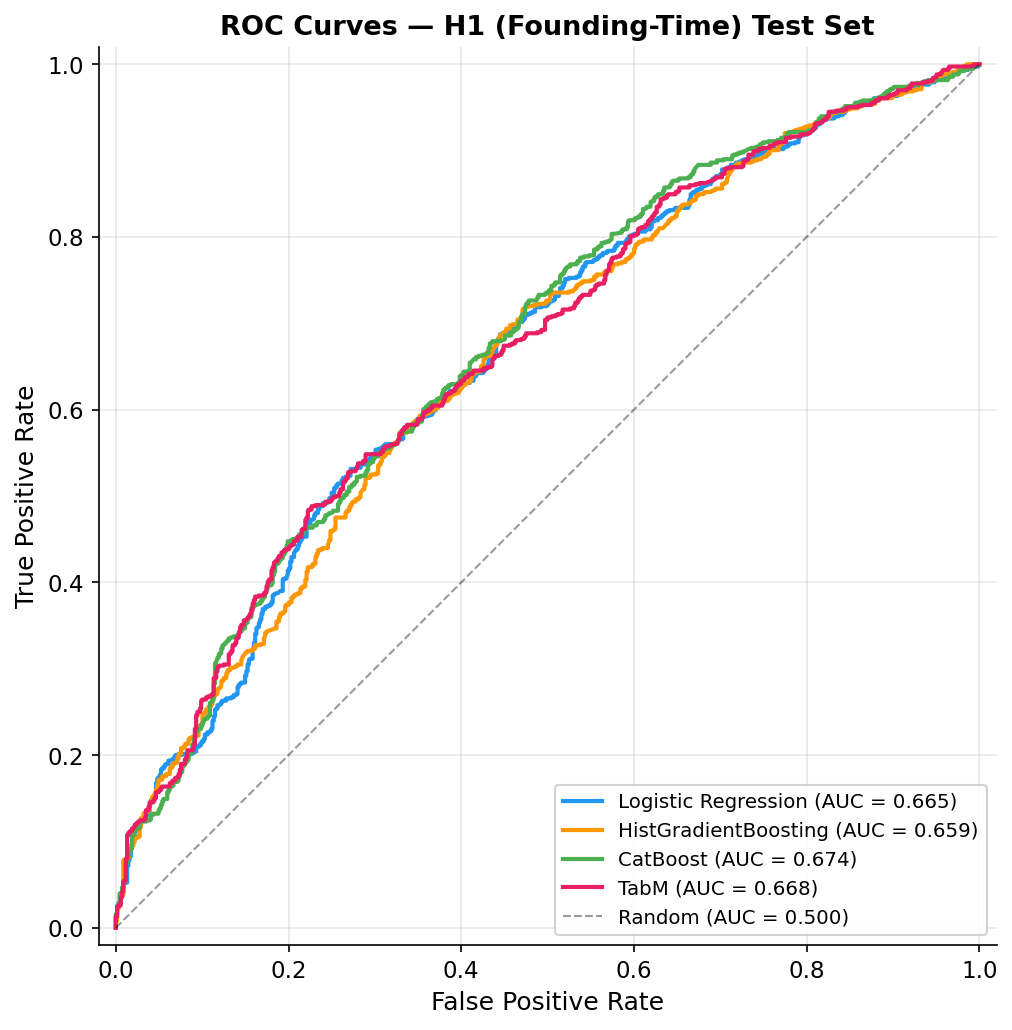

Saved: figures/15_roc_curves_h1.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

y_true_h1 = splits['H1']['test'][1].values
model_names_h1 = ['LogisticRegression', 'HistGradientBoosting', 'CatBoost', 'TabM']
model_labels = {'LogisticRegression': 'Logistic Regression',
                'HistGradientBoosting': 'HistGradientBoosting',
                'CatBoost': 'CatBoost',
                'TabM': 'TabM'}

for i, model_name in enumerate(model_names_h1):
    key = ('H1', model_name, 'test')
    if key not in predictions:
        continue
    y_prob = predictions[key]
    fpr, tpr, _ = roc_curve(y_true_h1, y_prob)
    auc = roc_auc_score(y_true_h1, y_prob)
    label = f"{model_labels[model_name]} (AUC = {auc:.3f})"
    ax.plot(fpr, tpr, color=COLORS[i], linewidth=2, label=label)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — H1 (Founding-Time) Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9.5, framealpha=0.9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_DIR / '15_roc_curves_h1.png', bbox_inches='tight')
plt.show()
print("Saved: figures/15_roc_curves_h1.png")


## 5.4 Precision-Recall Curves — All Models on H1

PR curves focus on the positive class (acquired). More informative than ROC under class imbalance, showing the trade-off between precision and recall.

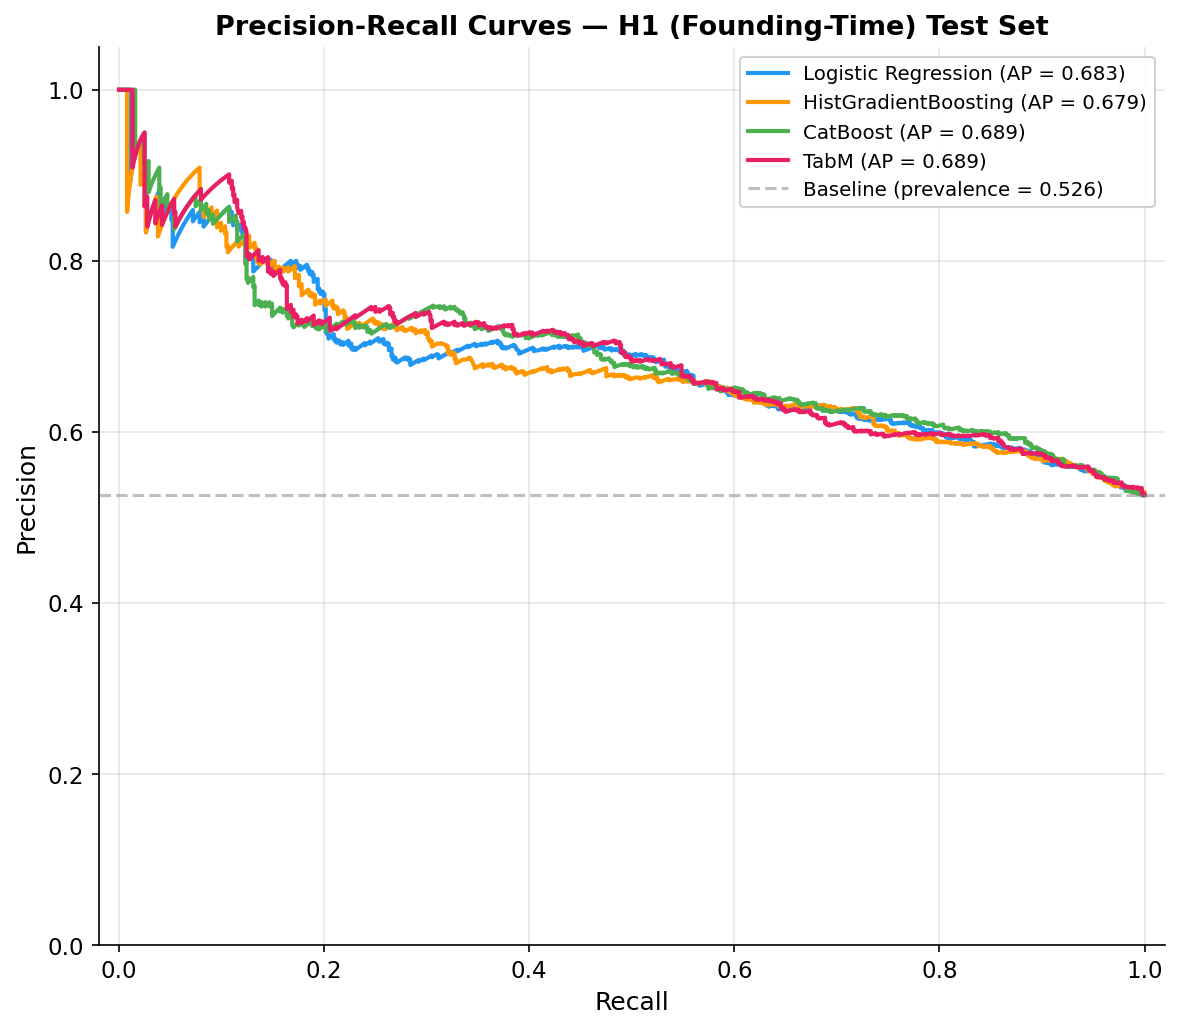

Saved: figures/16_pr_curves_h1.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))

y_true_h1 = splits['H1']['test'][1].values
baseline_pr = y_true_h1.mean()

for i, model_name in enumerate(model_names_h1):
    key = ('H1', model_name, 'test')
    if key not in predictions:
        continue
    y_prob = predictions[key]
    precision, recall, _ = precision_recall_curve(y_true_h1, y_prob)
    ap = average_precision_score(y_true_h1, y_prob)
    label = f"{model_labels[model_name]} (AP = {ap:.3f})"
    ax.plot(recall, precision, color=COLORS[i], linewidth=2, label=label)

# Random baseline
ax.axhline(y=baseline_pr, color='gray', linestyle='--', alpha=0.5,
           label=f'Baseline (prevalence = {baseline_pr:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — H1 (Founding-Time) Test Set',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9.5, framealpha=0.9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '16_pr_curves_h1.png', bbox_inches='tight')
plt.show()
print("Saved: figures/16_pr_curves_h1.png")


## 5.5 Confusion Matrices

Confusion matrices for the best model (CatBoost) on each horizon at the default 0.5 threshold. Shows how classification patterns change across horizons.

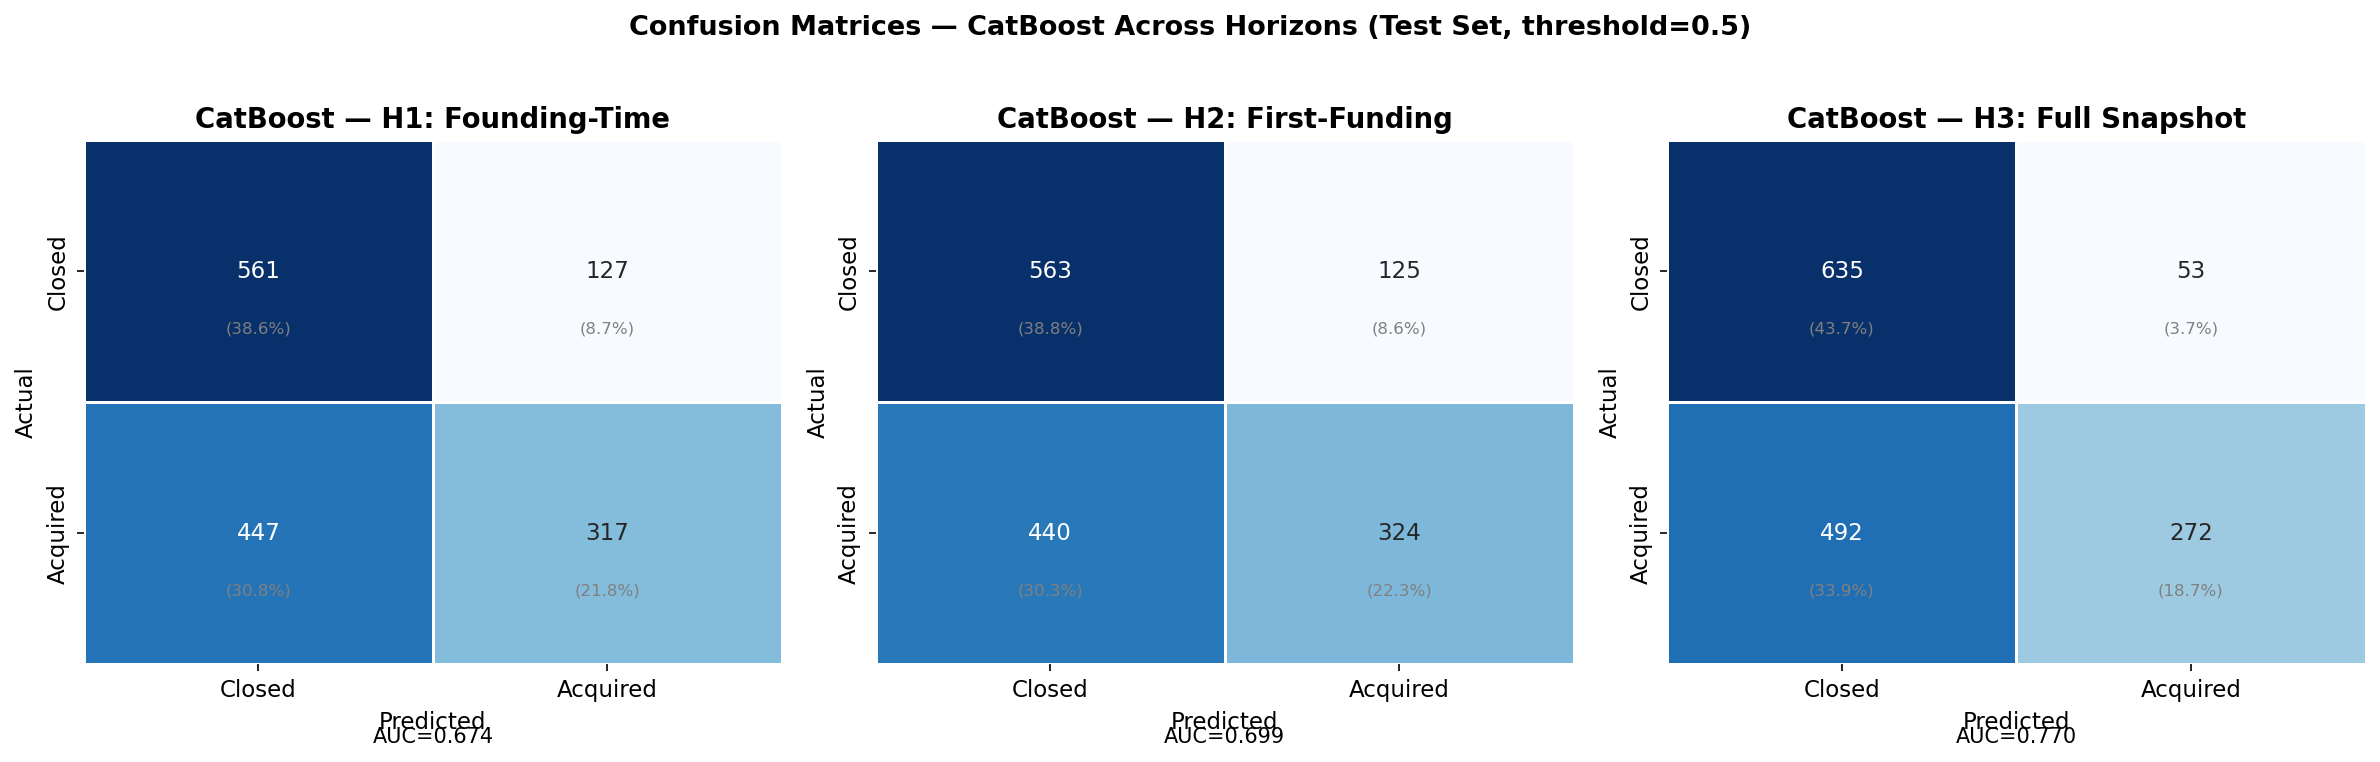

Saved: figures/17_confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

horizons = ['H1', 'H2', 'H3']
titles = ['H1: Founding-Time', 'H2: First-Funding', 'H3: Full Snapshot']

for idx, (horizon, title) in enumerate(zip(horizons, titles)):
    key = (horizon, 'CatBoost', 'test')
    if key not in predictions:
        continue
    y_true = splits[horizon]['test'][1].values
    y_prob = predictions[key]
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    # Normalise for display
    cm_pct = cm.astype(float) / cm.sum() * 100

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Closed', 'Acquired'],
                yticklabels=['Closed', 'Acquired'],
                cbar=False, linewidths=0.5)

    # Add percentages
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'({cm_pct[i, j]:.1f}%)',
                    ha='center', va='center', fontsize=8, color='gray')

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'CatBoost — {title}', fontweight='bold')
    auc = roc_auc_score(y_true, y_prob)
    ax.text(0.5, -0.15, f'AUC={auc:.3f}', transform=ax.transAxes,
            ha='center', fontsize=10)

plt.suptitle('Confusion Matrices — CatBoost Across Horizons (Test Set, threshold=0.5)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '17_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: figures/17_confusion_matrices.png")


## 5.6 Calibration Analysis

### 5.6.1 Calibration Plots (Before Calibration)

Are predicted probabilities reliable? A well-calibrated model's predicted probability p should correspond to a true positive rate of approximately p.

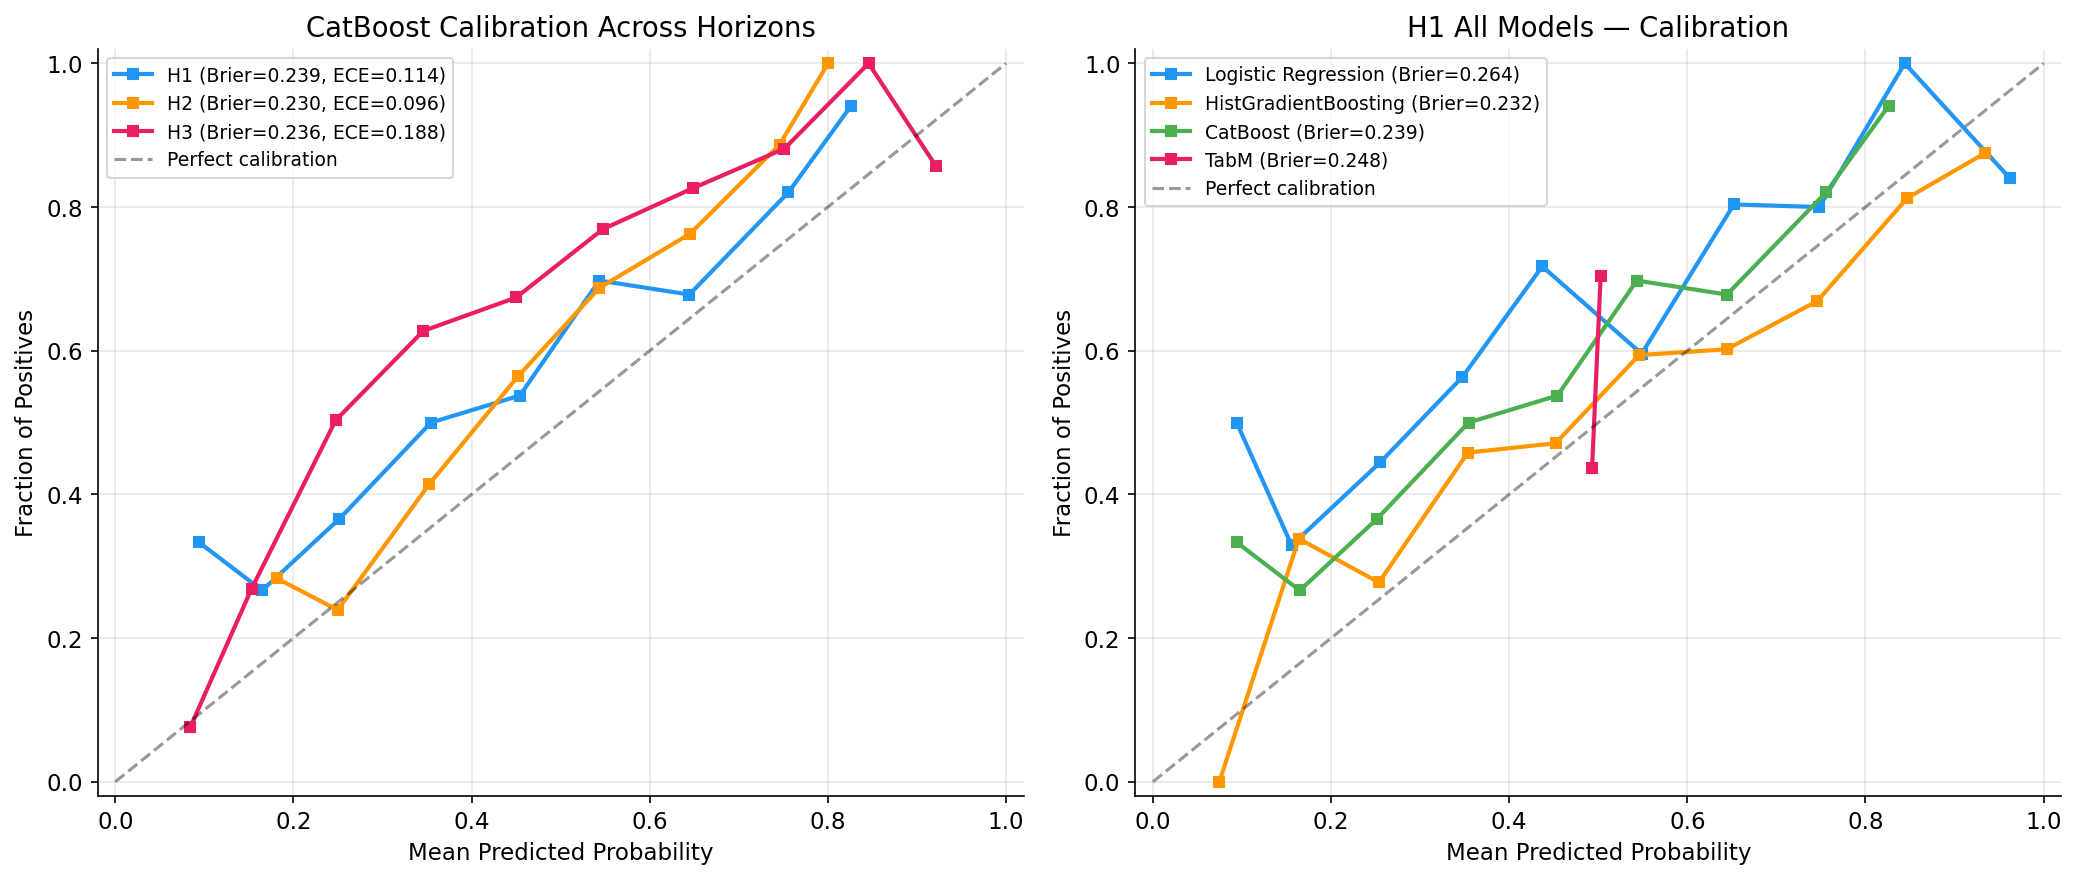

Saved: figures/18_calibration_plots.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: CatBoost across horizons ────────────────────────────
ax = axes[0]
for i, horizon in enumerate(['H1', 'H2', 'H3']):
    key = (horizon, 'CatBoost', 'test')
    if key not in predictions:
        continue
    y_true = splits[horizon]['test'][1].values
    y_prob = predictions[key]
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_true, y_prob)
    ece = expected_calibration_error(y_true, y_prob)
    label = f'{horizon} (Brier={brier:.3f}, ECE={ece:.3f})'
    ax.plot(prob_pred, prob_true, 's-', color=list(horizon_colors.values())[i],
            linewidth=2, markersize=5, label=label)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('CatBoost Calibration Across Horizons')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# ── Panel 2: All H1 models ──────────────────────────────────────
ax = axes[1]
for i, model_name in enumerate(model_names_h1):
    key = ('H1', model_name, 'test')
    if key not in predictions:
        continue
    y_true = splits['H1']['test'][1].values
    y_prob = predictions[key]
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_true, y_prob)
    label = f'{model_labels[model_name]} (Brier={brier:.3f})'
    ax.plot(prob_pred, prob_true, 's-', color=COLORS[i],
            linewidth=2, markersize=5, label=label)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('H1 All Models — Calibration')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / '18_calibration_plots.png', bbox_inches='tight')
plt.show()
print("Saved: figures/18_calibration_plots.png")


### 5.6.2 Post-hoc Calibration (Platt Scaling & Isotonic Regression)

Calibrate CatBoost (best model) on H1 and H2 using validation data. Compare Brier scores and ECE before and after calibration.

In [9]:
# ── Calibrate CatBoost on H1 and H2 ──────────────────────────────
calibration_results = []

for horizon in ['H1', 'H2']:
    # Get val and test predictions
    val_key = (horizon, 'CatBoost', 'val')
    test_key = (horizon, 'CatBoost', 'test')
    y_val = splits[horizon]['val'][1].values
    y_test = splits[horizon]['test'][1].values
    prob_val = predictions[val_key]
    prob_test = predictions[test_key]

    # Before calibration
    brier_before = brier_score_loss(y_test, prob_test)
    ece_before = expected_calibration_error(y_test, prob_test)

    # Platt scaling (logistic regression on val probabilities)
    platt = LR_calibrator(C=1e10, solver='lbfgs', max_iter=1000)
    platt.fit(prob_val.reshape(-1, 1), y_val)
    prob_test_platt = platt.predict_proba(prob_test.reshape(-1, 1))[:, 1]
    brier_platt = brier_score_loss(y_test, prob_test_platt)
    ece_platt = expected_calibration_error(y_test, prob_test_platt)

    # Isotonic regression on val probabilities
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(prob_val, y_val)
    prob_test_iso = iso.predict(prob_test)
    brier_iso = brier_score_loss(y_test, prob_test_iso)
    ece_iso = expected_calibration_error(y_test, prob_test_iso)

    # Store calibrated predictions for later use
    predictions[(horizon, 'CatBoost_Platt', 'test')] = prob_test_platt
    predictions[(horizon, 'CatBoost_Iso', 'test')] = prob_test_iso

    calibration_results.append({
        'Horizon': horizon, 'Method': 'Uncalibrated',
        'Brier': brier_before, 'ECE': ece_before,
        'AUC': roc_auc_score(y_test, prob_test),
    })
    calibration_results.append({
        'Horizon': horizon, 'Method': 'Platt Scaling',
        'Brier': brier_platt, 'ECE': ece_platt,
        'AUC': roc_auc_score(y_test, prob_test_platt),
    })
    calibration_results.append({
        'Horizon': horizon, 'Method': 'Isotonic Regression',
        'Brier': brier_iso, 'ECE': ece_iso,
        'AUC': roc_auc_score(y_test, prob_test_iso),
    })

    print(f"\n{horizon} CatBoost Calibration:")
    print(f"  Uncalibrated:  Brier={brier_before:.4f}, ECE={ece_before:.4f}")
    print(f"  Platt:         Brier={brier_platt:.4f}, ECE={ece_platt:.4f}")
    print(f"  Isotonic:      Brier={brier_iso:.4f}, ECE={ece_iso:.4f}")

cal_df = pd.DataFrame(calibration_results)
display(cal_df.round(4))



H1 CatBoost Calibration:
  Uncalibrated:  Brier=0.2393, ECE=0.1136
  Platt:         Brier=0.2283, ECE=0.0466
  Isotonic:      Brier=0.2285, ECE=0.0416

H2 CatBoost Calibration:
  Uncalibrated:  Brier=0.2296, ECE=0.0959
  Platt:         Brier=0.2206, ECE=0.0398
  Isotonic:      Brier=0.2211, ECE=0.0413


,Horizon,Method,Brier,ECE,AUC
0,H1,Uncalibrated,0.2393,0.1136,0.6739
1,H1,Platt Scaling,0.2283,0.0466,0.6739
2,H1,Isotonic Regression,0.2285,0.0416,0.6727
3,H2,Uncalibrated,0.2296,0.0959,0.6995
4,H2,Platt Scaling,0.2206,0.0398,0.6995
5,H2,Isotonic Regression,0.2211,0.0413,0.6970


### 5.6.3 Calibration Comparison Plot

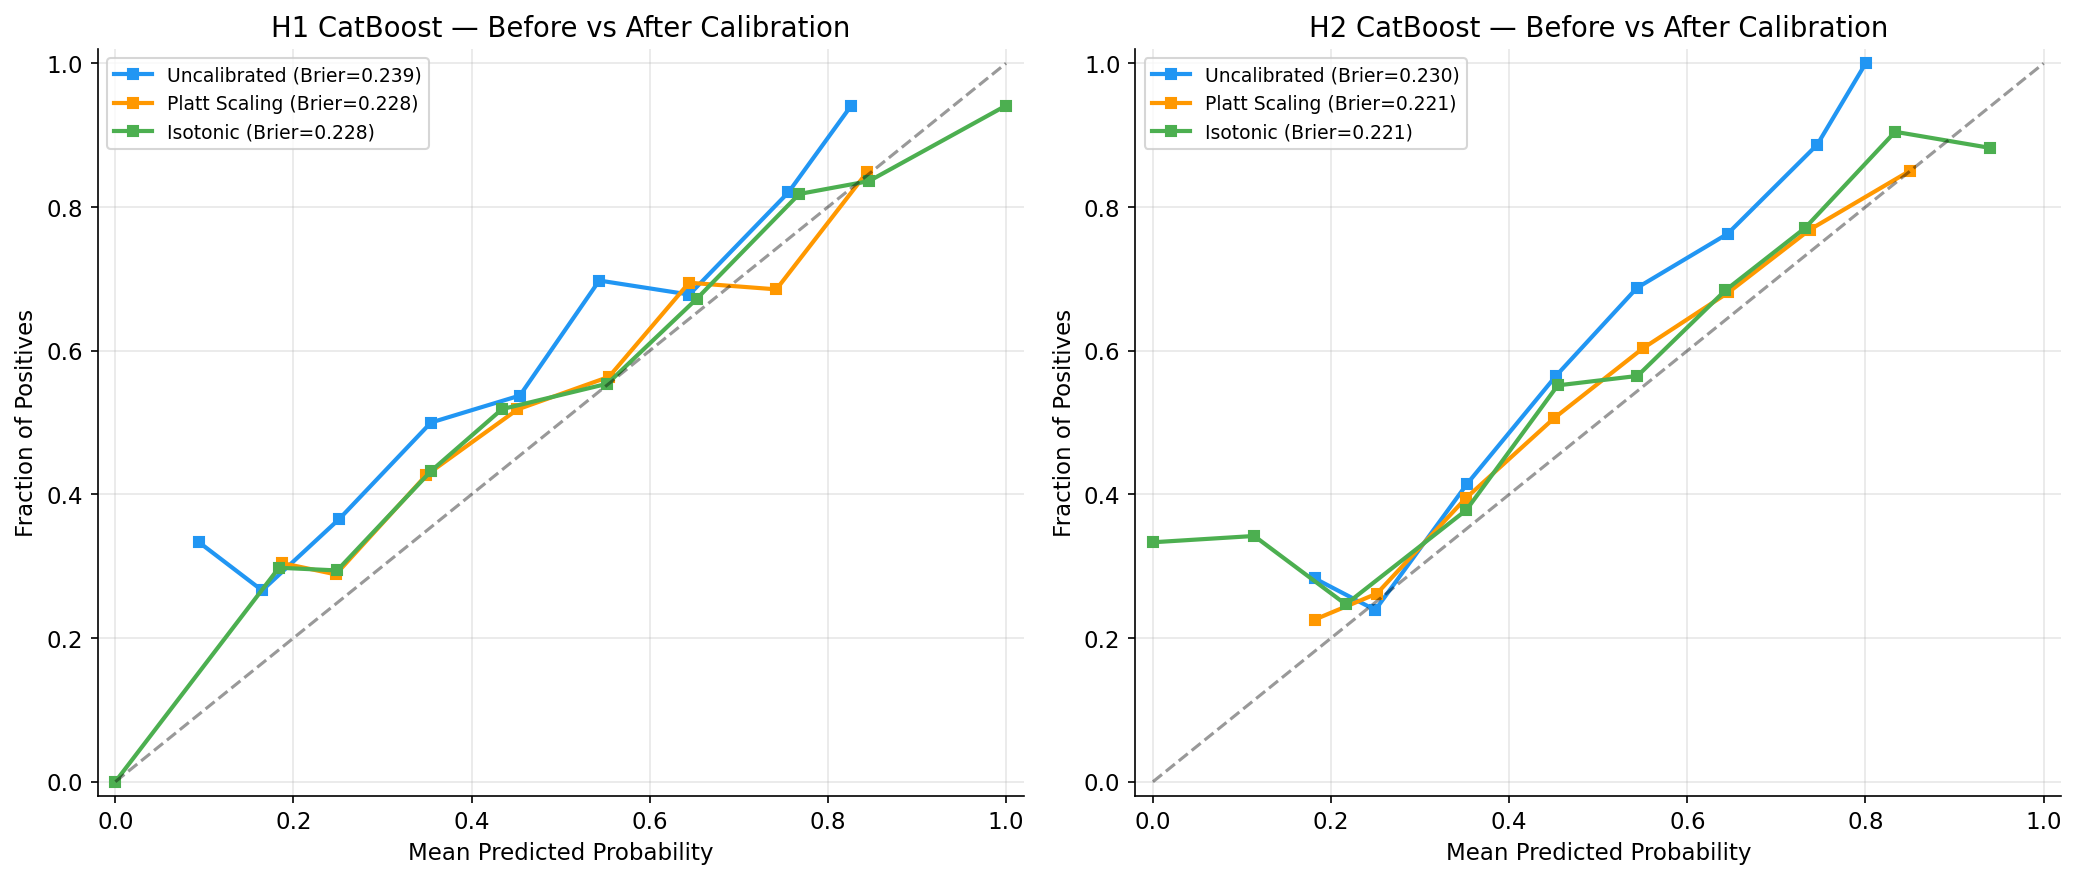

Saved: figures/18b_calibration_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, horizon in enumerate(['H1', 'H2']):
    ax = axes[idx]
    y_test = splits[horizon]['test'][1].values

    methods = [
        ('Uncalibrated', predictions[(horizon, 'CatBoost', 'test')], '#2196F3'),
        ('Platt Scaling', predictions[(horizon, 'CatBoost_Platt', 'test')], '#FF9800'),
        ('Isotonic', predictions[(horizon, 'CatBoost_Iso', 'test')], '#4CAF50'),
    ]

    for label, probs, color in methods:
        prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
        brier = brier_score_loss(y_test, probs)
        ax.plot(prob_pred, prob_true, 's-', color=color, linewidth=2, markersize=5,
                label=f'{label} (Brier={brier:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{horizon} CatBoost — Before vs After Calibration')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / '18b_calibration_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: figures/18b_calibration_comparison.png")


## 5.7 SHAP Analysis

### 5.7.1 SHAP Summary Plot (Bee Swarm) — CatBoost on H1

SHAP (SHapley Additive exPlanations) values decompose each prediction into per-feature contributions. The bee swarm plot shows the distribution and direction of feature effects across all test observations.

SHAP values shape: (1452, 11)
Features: ['country_code', 'state_code', 'region', 'city', 'founding_year', 'founding_quarter', 'num_categories', 'primary_category', 'market_clean', 'is_usa', 'has_state']


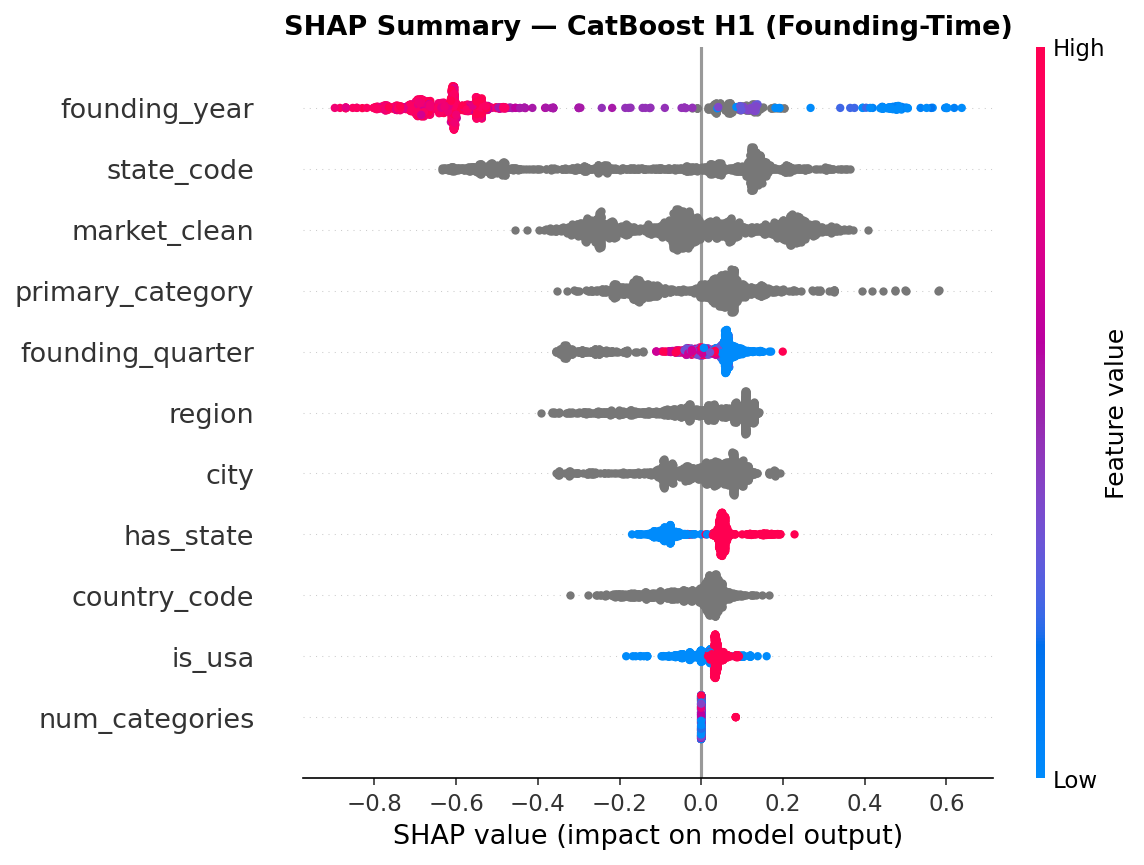

Saved: figures/19_shap_summary_h1.png


In [11]:
import shap

# ── SHAP for CatBoost H1 ─────────────────────────────────────────
cb_model = models['H1_CatBoost']
X_test_h1, y_test_h1 = splits['H1']['test']
X_test_cb, cat_idx = prepare_catboost_data(X_test_h1)

# Use TreeExplainer (fast, exact for tree models)
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test_cb)

# Save for reuse
np.save(FIG_DIR / 'shap_values_h1_catboost.npy', shap_values)
print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {list(X_test_cb.columns)}")

# ── Bee swarm plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_cb, show=False, max_display=15)
plt.title('SHAP Summary — CatBoost H1 (Founding-Time)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '19_shap_summary_h1.png', bbox_inches='tight')
plt.show()
print("Saved: figures/19_shap_summary_h1.png")


### 5.7.2 SHAP Dependence Plots — Top Features

Dependence plots show how individual feature values relate to their SHAP values, revealing non-linear effects and interactions.

Top 3 features by mean |SHAP|: ['founding_year', 'state_code', 'market_clean']


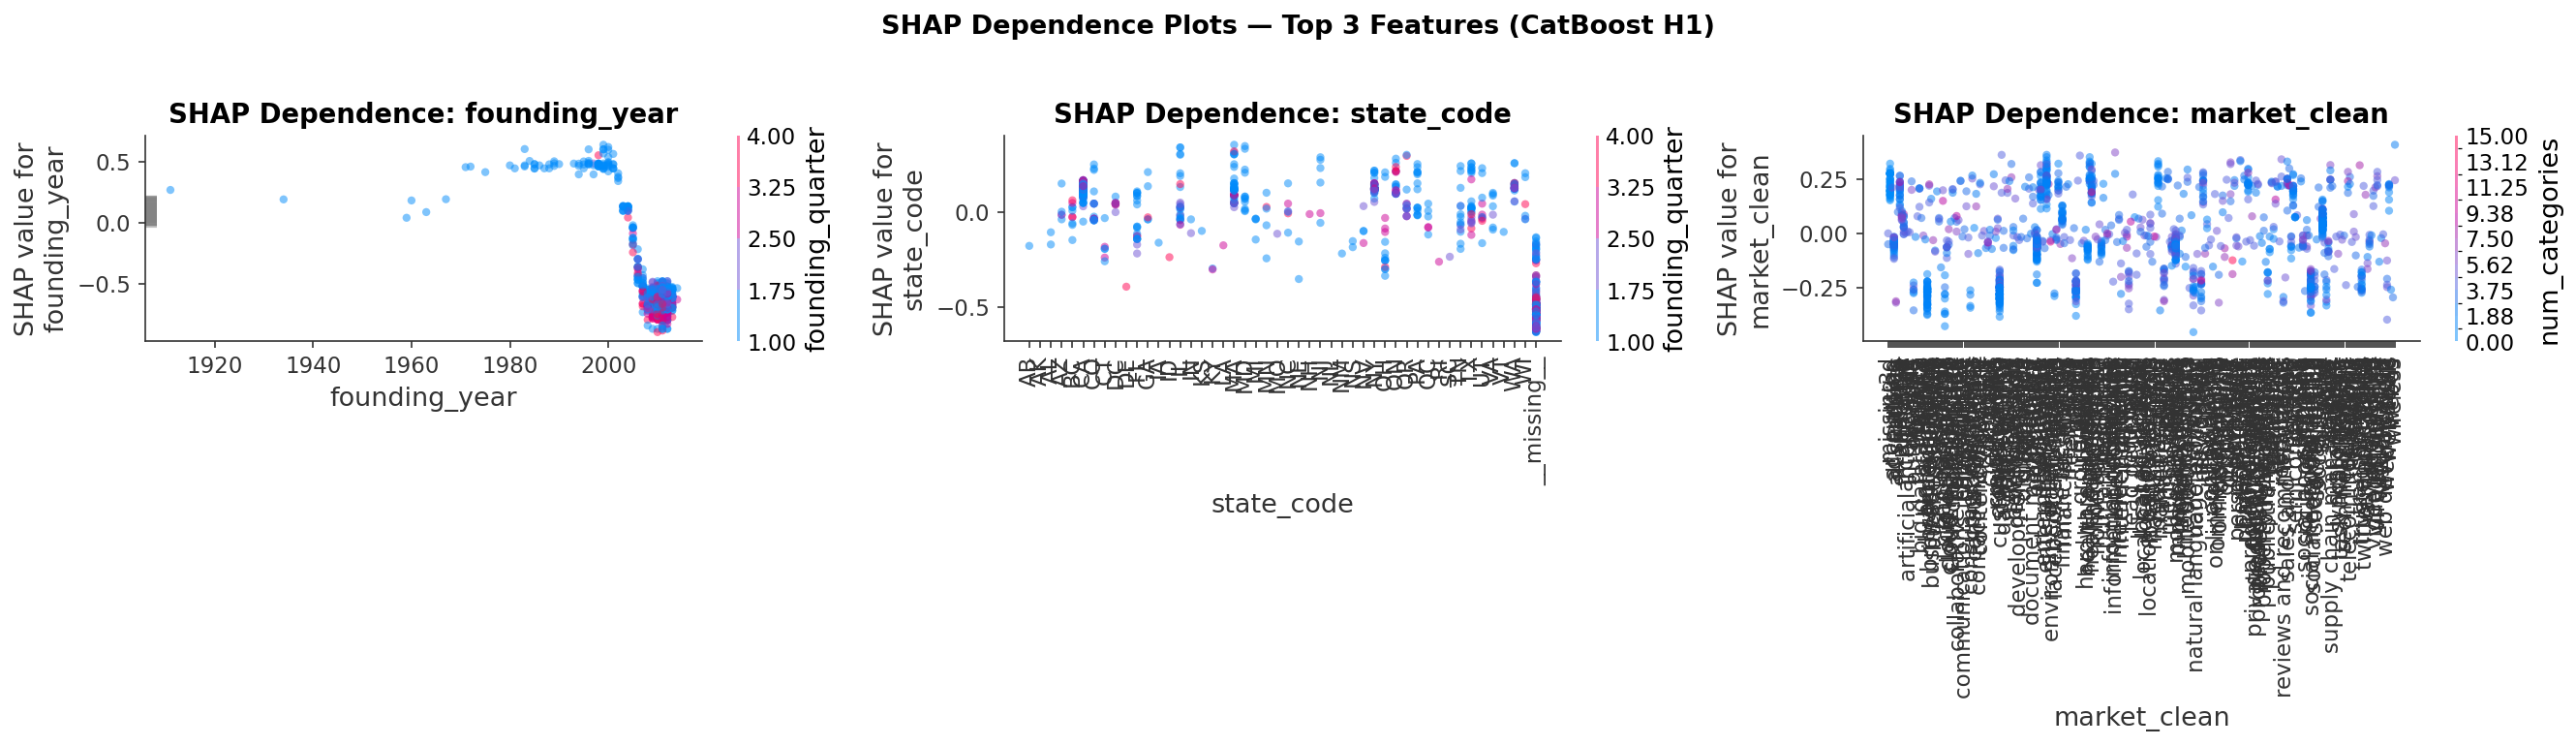

Saved: figures/20_shap_dependence_plots.png


In [12]:
# ── Top 3 features by mean |SHAP| ────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = X_test_cb.columns[np.argsort(-mean_abs_shap)[:3]].tolist()
print(f"Top 3 features by mean |SHAP|: {top_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feat in enumerate(top_features):
    ax = axes[idx]
    feat_idx = list(X_test_cb.columns).index(feat)
    shap.dependence_plot(feat_idx, shap_values, X_test_cb,
                         ax=ax, show=False, alpha=0.5)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 3 Features (CatBoost H1)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '20_shap_dependence_plots.png', bbox_inches='tight')
plt.show()
print("Saved: figures/20_shap_dependence_plots.png")


### 5.7.3 Cross-Model Feature Importance Comparison

Compare how different models weight features on H1. Shows whether models agree on which founding-time features matter most.

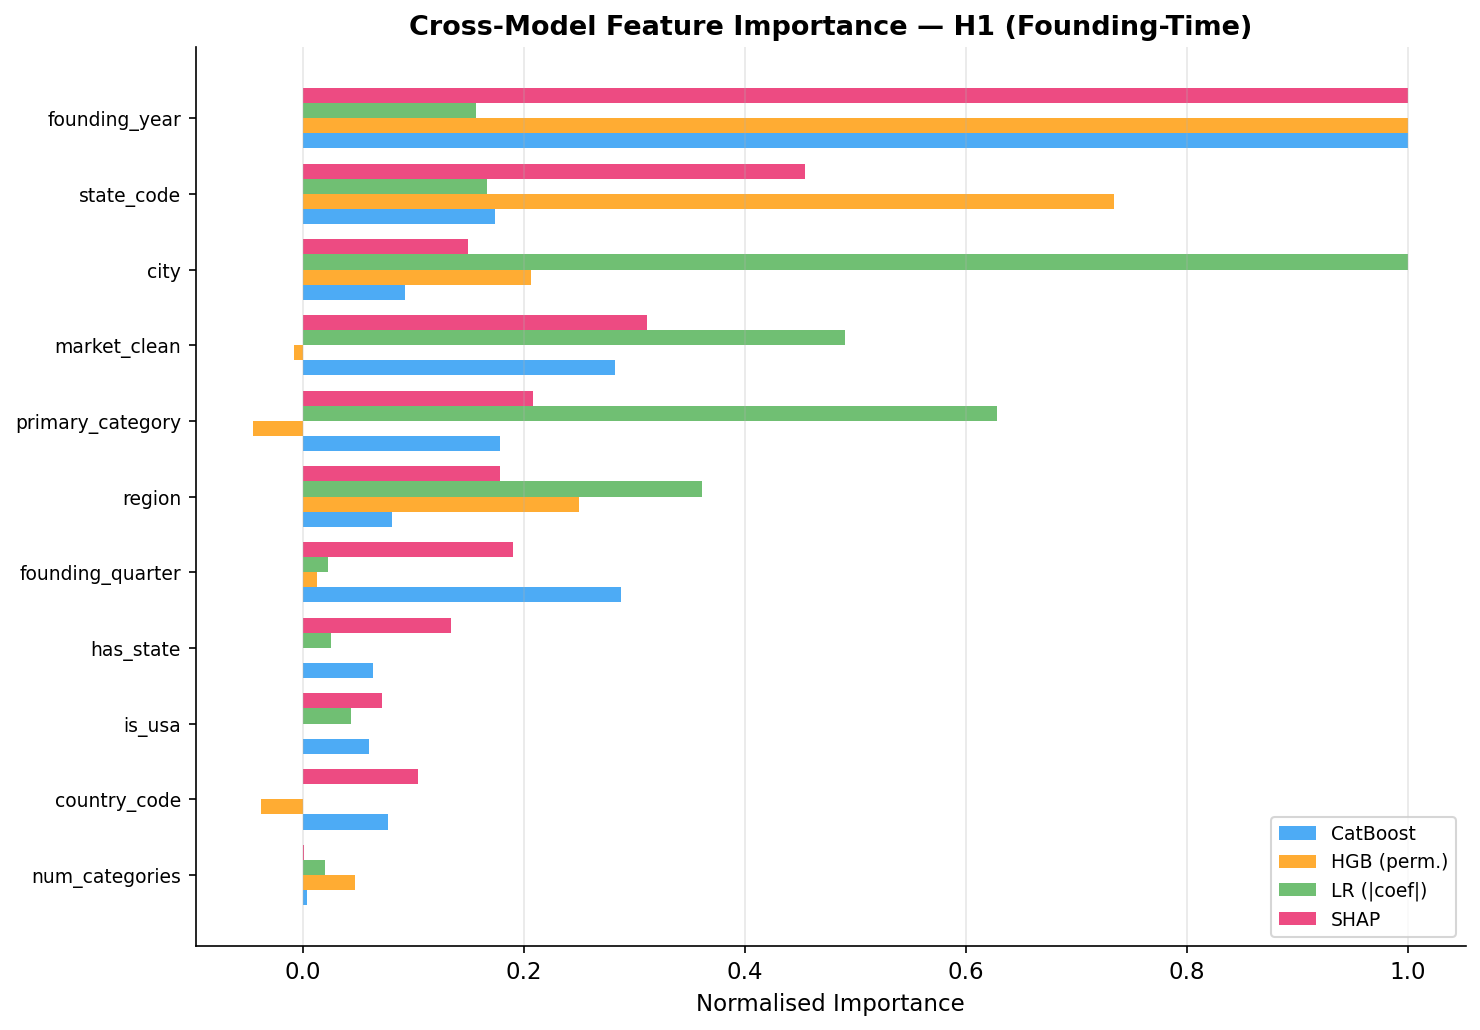

Saved: figures/21_cross_model_feature_importance.png

Top features by average normalised importance:
  founding_year: avg=0.789
  state_code: avg=0.382
  city: avg=0.362
  market_clean: avg=0.269
  primary_category: avg=0.243


In [13]:
from sklearn.inspection import permutation_importance

# ── CatBoost feature importance ──────────────────────────────────
cb_model_h1 = models['H1_CatBoost']
cb_features = list(X_test_cb.columns)
cb_importance = cb_model_h1.feature_importances_
cb_imp_df = pd.DataFrame({'feature': cb_features, 'CatBoost': cb_importance})

# ── LogisticRegression coefficients (absolute) ───────────────────
lr_pipe_h1 = models['H1_LogisticRegression']
lr_prep = lr_pipe_h1.named_steps['prep']
lr_clf = lr_pipe_h1.named_steps['clf']
lr_features = lr_prep.get_feature_names_out()
lr_features_clean = [f.split('__')[-1] for f in lr_features]
lr_coefs = np.abs(lr_clf.coef_[0])
lr_imp_df = pd.DataFrame({'feature': lr_features_clean, 'LR (|coef|)': lr_coefs})

# ── HGB permutation importance (feature_importances_ not available in sklearn 1.6) ──
hgb_pipe_h1 = models['H1_HistGradientBoosting']
hgb_prep = hgb_pipe_h1.named_steps['prep']
hgb_features = hgb_prep.get_feature_names_out()
hgb_features_clean = [f.split('__')[-1] for f in hgb_features]
# Use permutation importance on val set (fast, reliable)
X_val_h1, y_val_h1 = splits['H1']['val']
perm_result = permutation_importance(
    hgb_pipe_h1, X_val_h1, y_val_h1,
    n_repeats=10, random_state=SEED, scoring='roc_auc')
hgb_perm_imp = perm_result.importances_mean
# Map permutation importance back to original feature names
hgb_imp_df = pd.DataFrame({'feature': list(X_val_h1.columns), 'HGB': hgb_perm_imp})

# ── SHAP-based importance for CatBoost ───────────────────────────
shap_importance = np.abs(shap_values).mean(axis=0)
shap_imp_df = pd.DataFrame({'feature': cb_features, 'SHAP (mean |val|)': shap_importance})

# ── Merge all ────────────────────────────────────────────────────
imp_merged = cb_imp_df.merge(hgb_imp_df, on='feature', how='outer')
imp_merged = imp_merged.merge(lr_imp_df, on='feature', how='outer')
imp_merged = imp_merged.merge(shap_imp_df, on='feature', how='outer')
imp_merged = imp_merged.fillna(0)

# Normalise each to [0, 1] for comparison
for col in ['CatBoost', 'HGB', 'LR (|coef|)', 'SHAP (mean |val|)']:
    max_val = imp_merged[col].max()
    if max_val > 0:
        imp_merged[col + '_norm'] = imp_merged[col] / max_val
    else:
        imp_merged[col + '_norm'] = 0

# Sort by average normalised importance
imp_merged['avg_norm'] = imp_merged[['CatBoost_norm', 'HGB_norm',
                                      'LR (|coef|)_norm', 'SHAP (mean |val|)_norm']].mean(axis=1)
imp_merged = imp_merged.sort_values('avg_norm', ascending=True).tail(12)

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(imp_merged))
bar_h = 0.2
methods = [
    ('CatBoost_norm', 'CatBoost', '#2196F3'),
    ('HGB_norm', 'HGB (perm.)', '#FF9800'),
    ('LR (|coef|)_norm', 'LR (|coef|)', '#4CAF50'),
    ('SHAP (mean |val|)_norm', 'SHAP', '#E91E63'),
]

for i, (col, label, color) in enumerate(methods):
    ax.barh(y_pos + i * bar_h, imp_merged[col].values, bar_h,
            label=label, color=color, alpha=0.8)

ax.set_yticks(y_pos + 1.5 * bar_h)
ax.set_yticklabels(imp_merged['feature'].values, fontsize=9)
ax.set_xlabel('Normalised Importance', fontsize=11)
ax.set_title('Cross-Model Feature Importance — H1 (Founding-Time)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '21_cross_model_feature_importance.png', bbox_inches='tight')
plt.show()
print("Saved: figures/21_cross_model_feature_importance.png")

# Print top features
print("\nTop features by average normalised importance:")
for _, row in imp_merged.sort_values('avg_norm', ascending=False).head(5).iterrows():
    print(f"  {row['feature']}: avg={row['avg_norm']:.3f}")


## 5.8 TabM Training Curves

Training loss and validation AUC curves for the TabM deep learning model, demonstrating convergence behaviour. These were generated during Phase 4 training.

*(Figure 13 was saved during Phase 4. Displaying the saved image below.)*

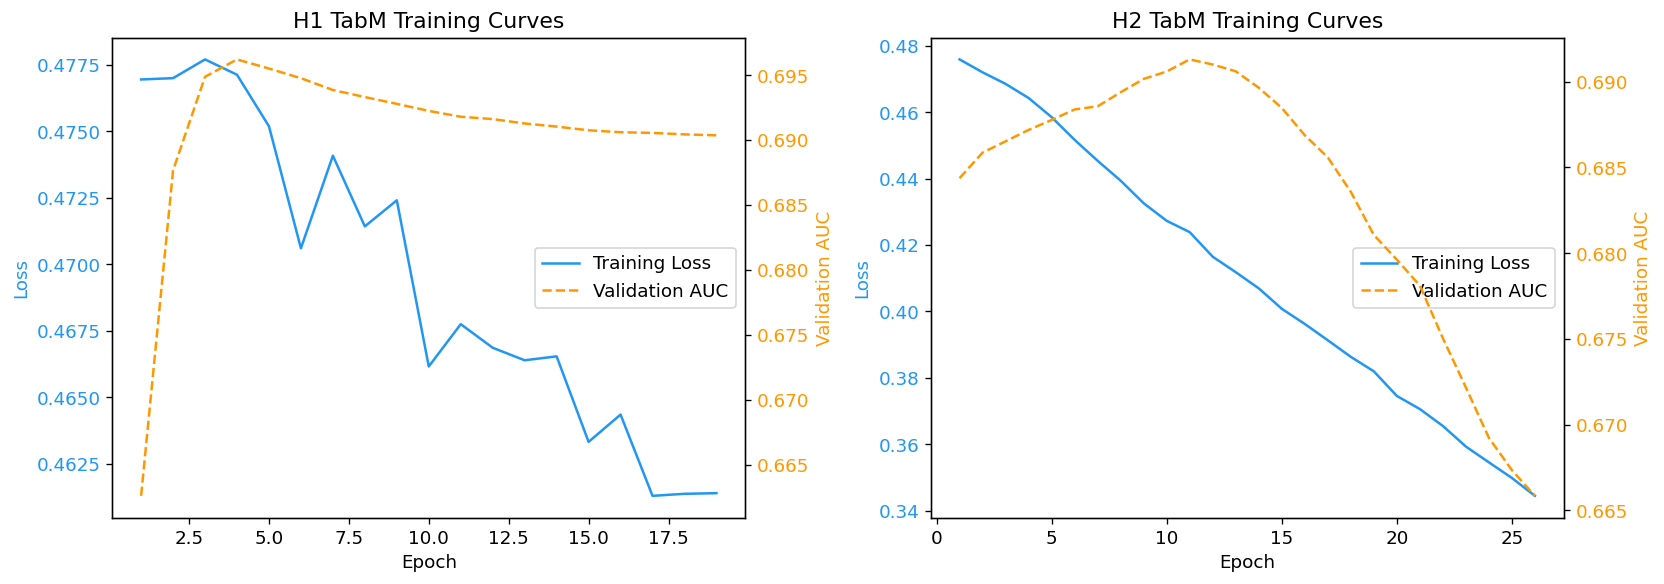

Displayed: figures/13_tabm_training_curves.png (from Phase 4)


In [14]:
from IPython.display import Image, display as ipy_display

img_path = FIG_DIR / '13_tabm_training_curves.png'
if img_path.exists():
    ipy_display(Image(filename=str(img_path), width=800))
    print("Displayed: figures/13_tabm_training_curves.png (from Phase 4)")
else:
    print("TabM training curves figure not found.")


## 5.9 Slice Analysis

Performance breakdown by year, sector, and geography on the H1 test set. Identifies subpopulations where the model performs differently — critical for understanding fairness and reliability.

/var/folders/ml/74nngzd13vz5grd47pckbf1w0000gn/T/ipykernel_63428/1784627586.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_slices = slice_df.groupby('founding_year').apply(compute_slice_metrics).dropna(subset=['auc'])
/var/folders/ml/74nngzd13vz5grd47pckbf1w0000gn/T/ipykernel_63428/1784627586.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_slice_metrics)
/var/folders/ml/74nngz

/var/folders/ml/74nngzd13vz5grd47pckbf1w0000gn/T/ipykernel_63428/1784627586.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_slice_metrics)


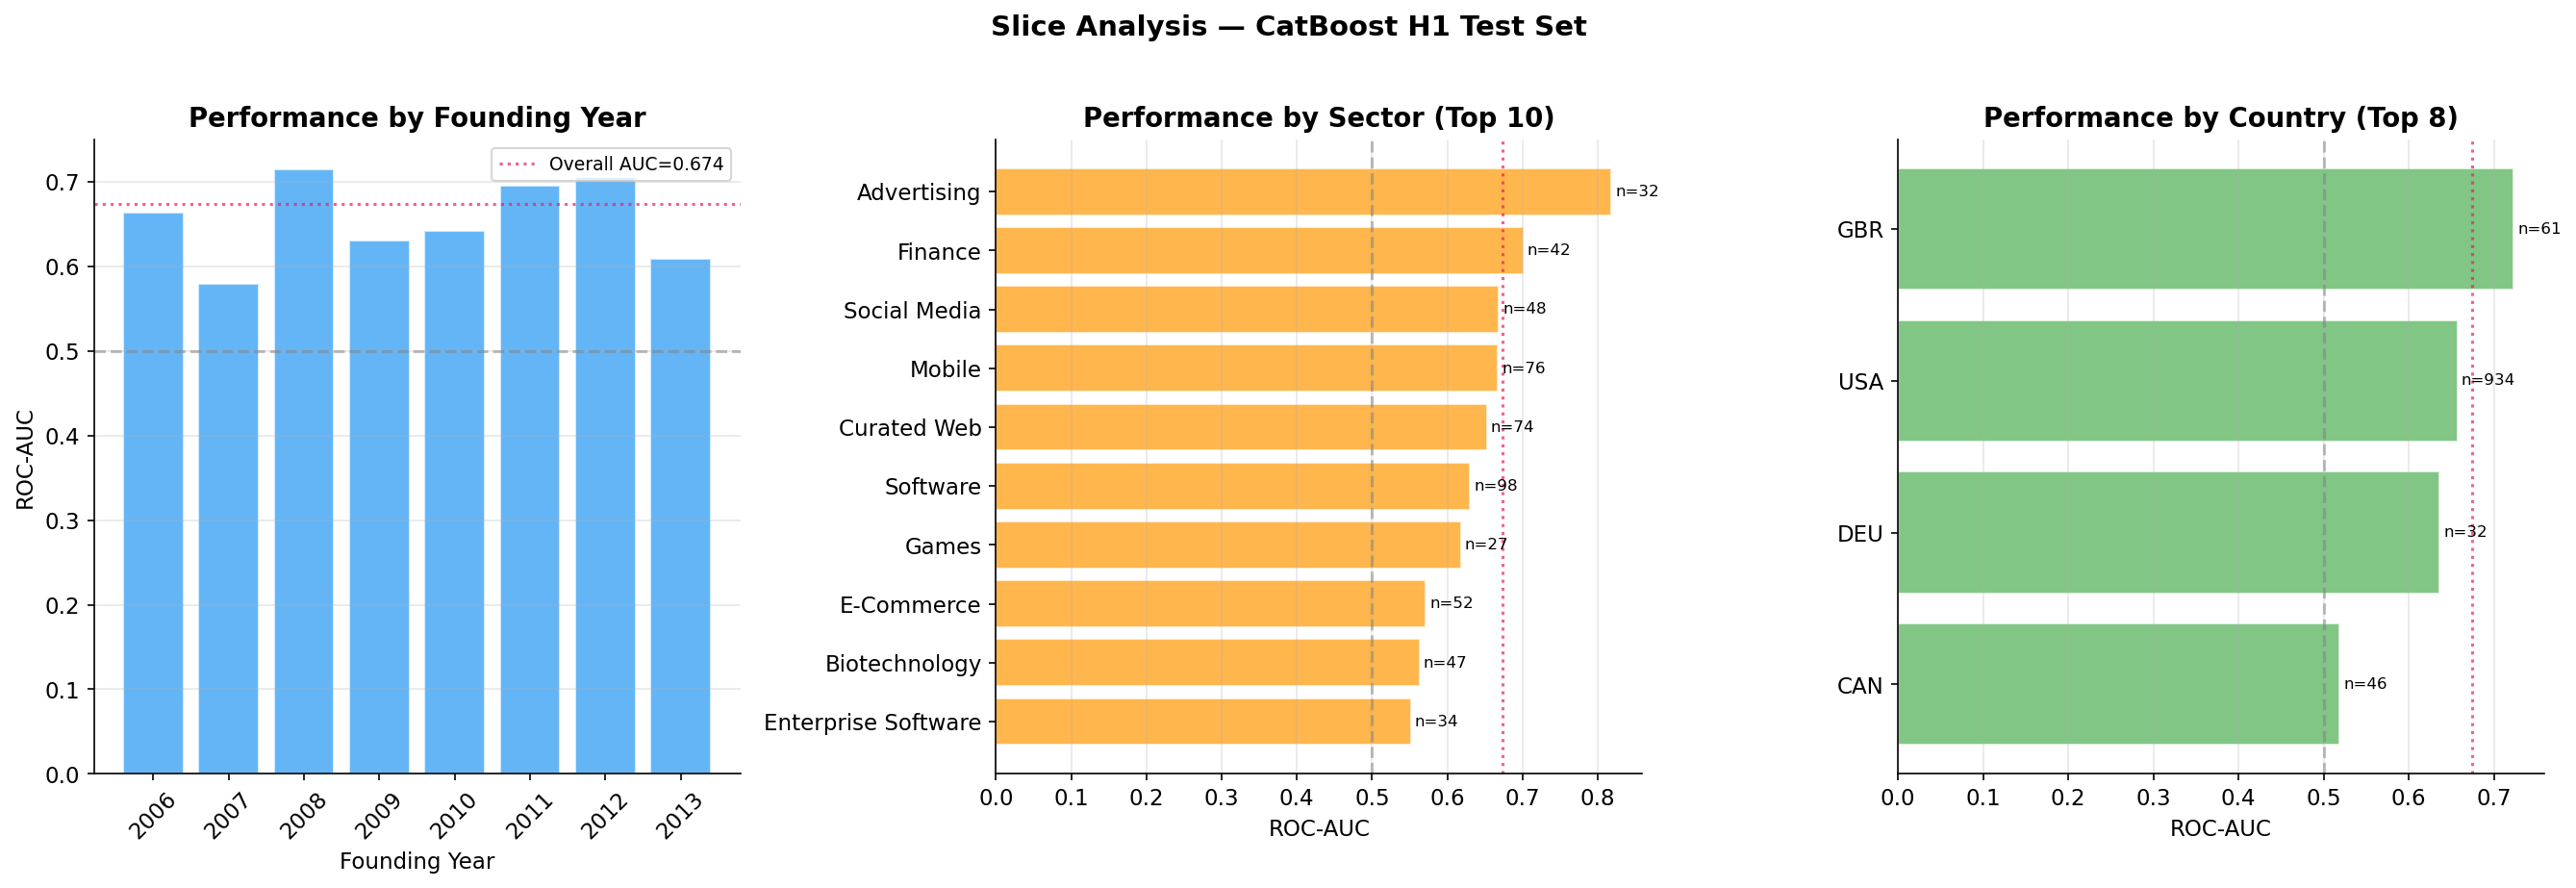

Saved: figures/22_slice_analysis.png

Slice Analysis Summary:
  Founding Year range: 2006 - 2013
  Year AUC range: 0.579 - 0.714
  Best country: GBR (AUC=0.723, n=61)
  Worst country: CAN (AUC=0.519, n=46)


In [15]:
# ── Use CatBoost H1 test predictions for slice analysis ──────────
X_test_h1, y_test_h1 = splits['H1']['test']
y_prob_cb_h1 = predictions[('H1', 'CatBoost', 'test')]

# Merge predictions with features for slicing
slice_df = X_test_h1.copy()
slice_df['y_true'] = y_test_h1.values
slice_df['y_prob'] = y_prob_cb_h1
slice_df['y_pred'] = (y_prob_cb_h1 >= 0.5).astype(int)

def compute_slice_metrics(group):
    """Compute metrics for a slice, requiring >= 20 samples and both classes."""
    if len(group) < 20 or group['y_true'].nunique() < 2:
        return pd.Series({'auc': np.nan, 'n': len(group), 'acq_rate': group['y_true'].mean()})
    auc = roc_auc_score(group['y_true'], group['y_prob'])
    return pd.Series({'auc': auc, 'n': len(group), 'acq_rate': group['y_true'].mean()})

# ── Figure: 3-panel slice analysis ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: By founding year
ax = axes[0]
year_slices = slice_df.groupby('founding_year').apply(compute_slice_metrics).dropna(subset=['auc'])
year_slices = year_slices.sort_index()
if not year_slices.empty:
    bars = ax.bar(year_slices.index.astype(int), year_slices['auc'],
                  color='#2196F3', alpha=0.7, edgecolor='white')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    overall_auc = roc_auc_score(y_test_h1, y_prob_cb_h1)
    ax.axhline(y=overall_auc, color='#E91E63', linestyle=':', alpha=0.7,
               label=f'Overall AUC={overall_auc:.3f}')
    ax.set_xlabel('Founding Year')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('Performance by Founding Year', fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

# Panel 2: By top sectors (primary_category)
ax = axes[1]
top_cats = slice_df['primary_category'].value_counts().head(10).index
cat_slices = (slice_df[slice_df['primary_category'].isin(top_cats)]
              .groupby('primary_category')
              .apply(compute_slice_metrics)
              .dropna(subset=['auc'])
              .sort_values('auc'))
if not cat_slices.empty:
    ax.barh(cat_slices.index, cat_slices['auc'], color='#FF9800', alpha=0.7,
            edgecolor='white')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=overall_auc, color='#E91E63', linestyle=':', alpha=0.7)
    # Add sample sizes
    for i, (cat, row) in enumerate(cat_slices.iterrows()):
        ax.text(row['auc'] + 0.005, i, f'n={int(row["n"])}', va='center', fontsize=8)
    ax.set_xlabel('ROC-AUC')
    ax.set_title('Performance by Sector (Top 10)', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

# Panel 3: By geography (USA vs non-USA, then top countries)
ax = axes[2]
# USA vs non-USA
geo_slices = slice_df.groupby('is_usa').apply(compute_slice_metrics).dropna(subset=['auc'])
# Top countries
top_countries = slice_df['country_code'].value_counts().head(8).index
country_slices = (slice_df[slice_df['country_code'].isin(top_countries)]
                  .groupby('country_code')
                  .apply(compute_slice_metrics)
                  .dropna(subset=['auc'])
                  .sort_values('auc'))
if not country_slices.empty:
    ax.barh(country_slices.index, country_slices['auc'], color='#4CAF50', alpha=0.7,
            edgecolor='white')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=overall_auc, color='#E91E63', linestyle=':', alpha=0.7)
    for i, (country, row) in enumerate(country_slices.iterrows()):
        ax.text(row['auc'] + 0.005, i, f'n={int(row["n"])}', va='center', fontsize=8)
    ax.set_xlabel('ROC-AUC')
    ax.set_title('Performance by Country (Top 8)', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Slice Analysis — CatBoost H1 Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '22_slice_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: figures/22_slice_analysis.png")

# ── Print slice summary ─────────────────────────────────────────
print("\nSlice Analysis Summary:")
if not year_slices.empty:
    print(f"  Founding Year range: {int(year_slices.index.min())} - {int(year_slices.index.max())}")
    print(f"  Year AUC range: {year_slices['auc'].min():.3f} - {year_slices['auc'].max():.3f}")
if not country_slices.empty:
    best_country = country_slices['auc'].idxmax()
    worst_country = country_slices['auc'].idxmin()
    print(f"  Best country: {best_country} (AUC={country_slices.loc[best_country, 'auc']:.3f}, n={int(country_slices.loc[best_country, 'n'])})")
    print(f"  Worst country: {worst_country} (AUC={country_slices.loc[worst_country, 'auc']:.3f}, n={int(country_slices.loc[worst_country, 'n'])})")


## 5.10 Error Analysis

Characteristics of misclassified examples — what makes some startups hard to predict? Comparing the distributions of correctly classified vs misclassified observations reveals systematic failure patterns.

Classification outcomes (threshold=0.5):
  Correct: 878 (60.5%)
  False Positives: 127 (8.7%)
  False Negatives: 447 (30.8%)


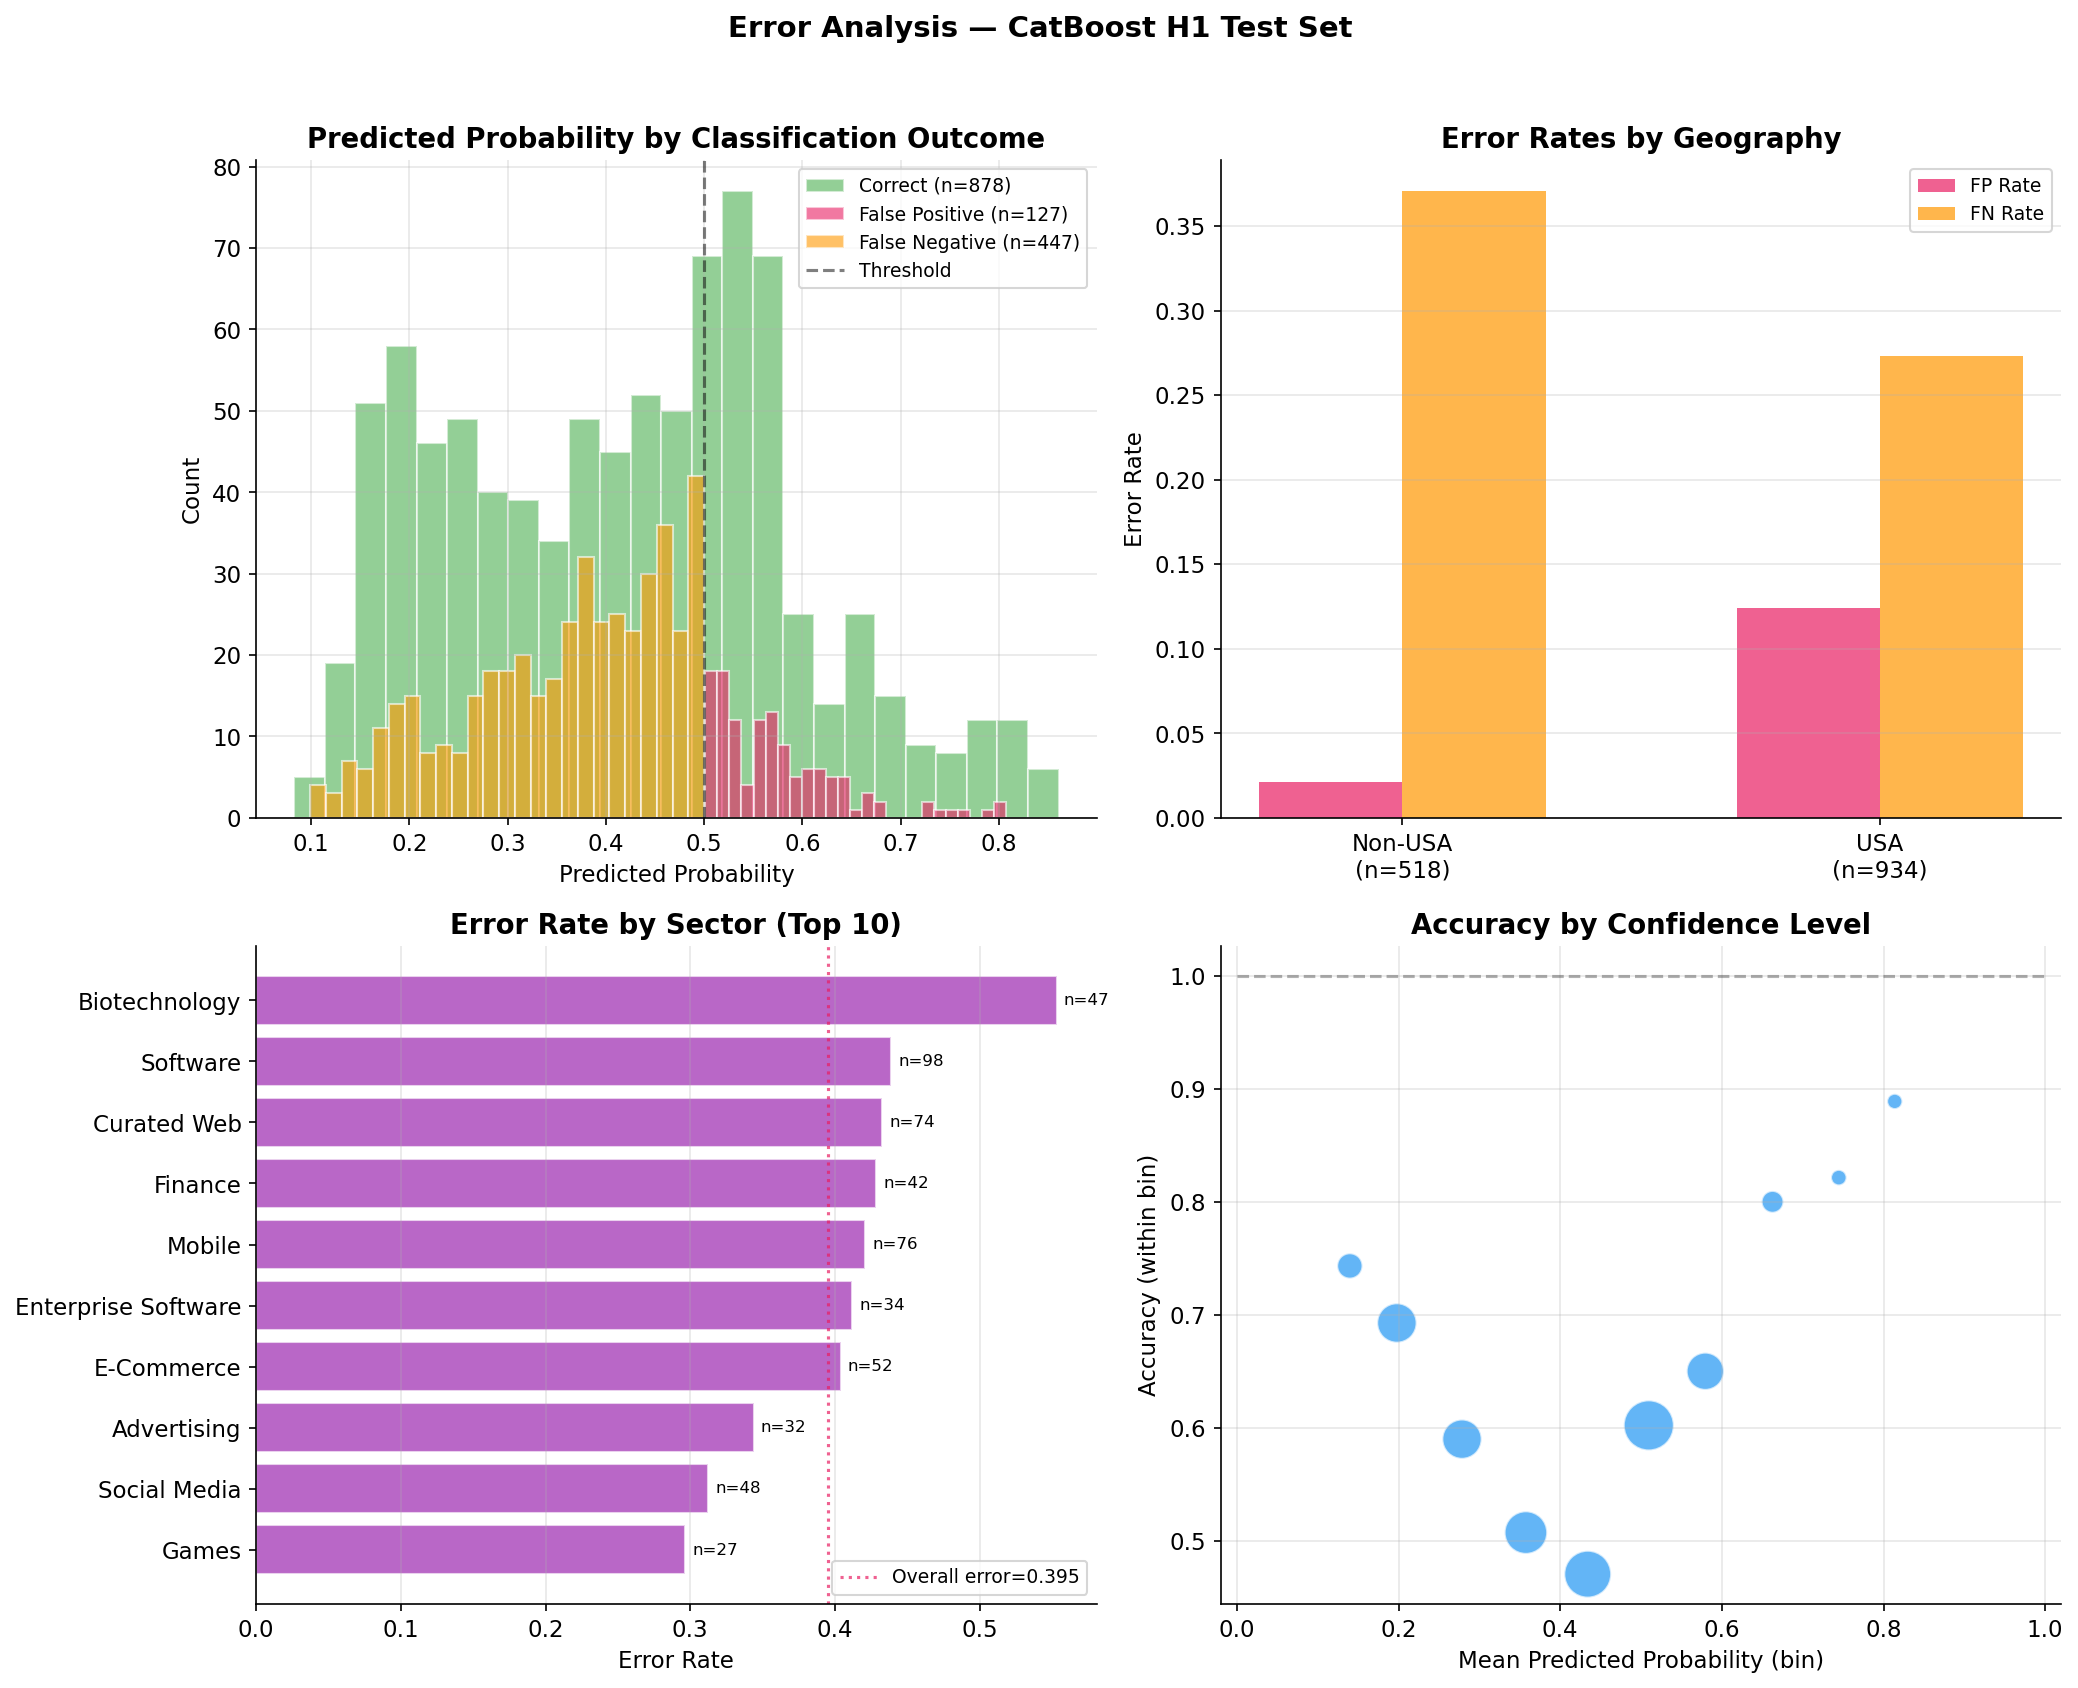

Saved: figures/23_error_analysis.png

Error Analysis Insights:
  Most confident FP: p=0.808 (predicted acquired, actually closed)
  Most confident FN: p=0.099 (predicted closed, actually acquired)
  Hardest sector: Biotechnology (error rate=0.553)


In [16]:
# ── Error analysis for CatBoost H1 ──────────────────────────────
X_test_h1, y_test_h1 = splits['H1']['test']
y_prob = predictions[('H1', 'CatBoost', 'test')]
y_pred = (y_prob >= 0.5).astype(int)
y_true = y_test_h1.values

# Classification outcomes
correct = (y_pred == y_true)
error_df = X_test_h1.copy()
error_df['y_true'] = y_true
error_df['y_prob'] = y_prob
error_df['y_pred'] = y_pred
error_df['correct'] = correct
error_df['error_type'] = 'Correct'
error_df.loc[(y_pred == 1) & (y_true == 0), 'error_type'] = 'False Positive'
error_df.loc[(y_pred == 0) & (y_true == 1), 'error_type'] = 'False Negative'

n_fp = ((y_pred == 1) & (y_true == 0)).sum()
n_fn = ((y_pred == 0) & (y_true == 1)).sum()
n_correct = correct.sum()
print(f"Classification outcomes (threshold=0.5):")
print(f"  Correct: {n_correct} ({n_correct/len(y_true)*100:.1f}%)")
print(f"  False Positives: {n_fp} ({n_fp/len(y_true)*100:.1f}%)")
print(f"  False Negatives: {n_fn} ({n_fn/len(y_true)*100:.1f}%)")

# ── Figure: Error analysis panels ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel 1: Probability distribution by error type
ax = axes[0, 0]
for etype, color in [('Correct', '#4CAF50'), ('False Positive', '#E91E63'),
                      ('False Negative', '#FF9800')]:
    mask = error_df['error_type'] == etype
    if mask.sum() > 0:
        ax.hist(error_df.loc[mask, 'y_prob'], bins=25, alpha=0.6,
                label=f'{etype} (n={mask.sum()})', color=color, edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.set_title('Predicted Probability by Classification Outcome', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Error rate by USA vs non-USA
ax = axes[0, 1]
error_by_usa = error_df.groupby('is_usa').agg(
    error_rate=('correct', lambda x: 1 - x.mean()),
    n=('correct', 'count'),
    fp_rate=('error_type', lambda x: (x == 'False Positive').mean()),
    fn_rate=('error_type', lambda x: (x == 'False Negative').mean()),
).reset_index()
error_by_usa['label'] = error_by_usa['is_usa'].map({0: 'Non-USA', 1: 'USA'})
x_pos = np.arange(len(error_by_usa))
ax.bar(x_pos - 0.15, error_by_usa['fp_rate'], 0.3, label='FP Rate', color='#E91E63', alpha=0.7)
ax.bar(x_pos + 0.15, error_by_usa['fn_rate'], 0.3, label='FN Rate', color='#FF9800', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{r['label']}\n(n={r['n']})" for _, r in error_by_usa.iterrows()])
ax.set_ylabel('Error Rate')
ax.set_title('Error Rates by Geography', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 3: Error rate by top categories
ax = axes[1, 0]
top_cats = error_df['primary_category'].value_counts().head(10).index
cat_errors = (error_df[error_df['primary_category'].isin(top_cats)]
              .groupby('primary_category')
              .agg(error_rate=('correct', lambda x: 1 - x.mean()),
                   n=('correct', 'count'))
              .sort_values('error_rate'))
ax.barh(cat_errors.index, cat_errors['error_rate'], color='#9C27B0', alpha=0.7,
        edgecolor='white')
overall_error = 1 - correct.mean()
ax.axvline(x=overall_error, color='#E91E63', linestyle=':', alpha=0.7,
           label=f'Overall error={overall_error:.3f}')
for i, (cat, row) in enumerate(cat_errors.iterrows()):
    ax.text(row['error_rate'] + 0.005, i, f'n={int(row["n"])}', va='center', fontsize=8)
ax.set_xlabel('Error Rate')
ax.set_title('Error Rate by Sector (Top 10)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Panel 4: Confidence vs accuracy (reliability diagram for errors)
ax = axes[1, 1]
# Group by predicted probability bins
error_df['prob_bin'] = pd.cut(error_df['y_prob'], bins=10)
bin_stats = error_df.groupby('prob_bin', observed=True).agg(
    mean_prob=('y_prob', 'mean'),
    accuracy=('correct', 'mean'),
    n=('correct', 'count'),
).dropna()
ax.scatter(bin_stats['mean_prob'], bin_stats['accuracy'],
           s=bin_stats['n'] * 2, c='#2196F3', alpha=0.7, edgecolors='white')
ax.plot([0, 1], [1, 1], 'k--', alpha=0.3)
ax.set_xlabel('Mean Predicted Probability (bin)')
ax.set_ylabel('Accuracy (within bin)')
ax.set_title('Accuracy by Confidence Level', fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)

plt.suptitle('Error Analysis — CatBoost H1 Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '23_error_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: figures/23_error_analysis.png")

# ── Print error analysis insights ────────────────────────────────
print("\nError Analysis Insights:")

# Most confident errors
fp_mask = error_df['error_type'] == 'False Positive'
fn_mask = error_df['error_type'] == 'False Negative'
if fp_mask.sum() > 0:
    most_confident_fp = error_df.loc[fp_mask, 'y_prob'].max()
    print(f"  Most confident FP: p={most_confident_fp:.3f} (predicted acquired, actually closed)")
if fn_mask.sum() > 0:
    most_confident_fn = error_df.loc[fn_mask, 'y_prob'].min()
    print(f"  Most confident FN: p={most_confident_fn:.3f} (predicted closed, actually acquired)")

# Category with highest error rate (min 20 samples)
large_cats = cat_errors[cat_errors.index.isin(
    error_df['primary_category'].value_counts()[lambda x: x >= 20].index)]
if not large_cats.empty:
    worst_cat = large_cats['error_rate'].idxmax()
    print(f"  Hardest sector: {worst_cat} (error rate={large_cats.loc[worst_cat, 'error_rate']:.3f})")


## 5.11 Full Evaluation Metrics Table

Complete metrics across all models and horizons on the test set. This table becomes part of the report appendix.

In [17]:
# ── Rebuild full test metrics table ──────────────────────────────
full_results = []

for (horizon, model_name, split), y_prob in predictions.items():
    if split != 'test':
        continue
    if 'Platt' in model_name or 'Iso' in model_name:
        continue  # skip calibrated versions in main table
    y_true = splits[horizon]['test'][1].values
    metrics = compute_all_metrics(y_true, y_prob)
    metrics['Horizon'] = horizon
    metrics['Model'] = model_name
    full_results.append(metrics)

full_metrics_df = pd.DataFrame(full_results)
full_metrics_df = full_metrics_df[['Horizon', 'Model', 'roc_auc', 'pr_auc',
                                    'balanced_accuracy', 'f1', 'brier_score', 'ece']]
full_metrics_df = full_metrics_df.sort_values(['Horizon', 'roc_auc'], ascending=[True, False])

print("Full Test Set Metrics")
print("=" * 80)
display(full_metrics_df.round(4).reset_index(drop=True))

# ── Save to CSV ──────────────────────────────────────────────────
full_metrics_df.to_csv(DATA_DIR / 'evaluation_results.csv', index=False)
print(f"\nSaved: data/processed/evaluation_results.csv")


Full Test Set Metrics


,Horizon,Model,roc_auc,pr_auc,balanced_accuracy,f1,brier_score,ece
0,H1,CatBoost,0.6739,0.6887,0.6152,0.5248,0.2393,0.1136
1,H1,TabM,0.6677,0.6890,0.6198,0.5491,0.2484,0.1054
2,H1,LogisticRegression,0.6650,0.6826,0.5605,0.3494,0.2642,0.1842
3,H1,HistGradientBoosting,0.6589,0.6793,0.6143,0.6212,0.2324,0.0561
4,H2,CatBoost,0.6995,0.7076,0.6212,0.5342,0.2296,0.0959
5,H2,TabM,0.6741,0.6878,0.5818,0.4068,0.2404,0.1125
6,H2,HistGradientBoosting,0.6708,0.6802,0.6148,0.6675,0.2268,0.0311
7,H2,LogisticRegression,0.6401,0.6524,0.5593,0.3704,0.2426,0.0837
8,H3,CatBoost,0.7700,0.7745,0.6395,0.4995,0.2364,0.1882
9,H3,LogisticRegression,0.6831,0.7143,0.5753,0.3084,0.2441,0.0558



Saved: data/processed/evaluation_results.csv


## 5.12 Final Model Selection

Select the best model under a **valid horizon** (H1 or H2), NOT the highest H3 score. The H3 results demonstrate leakage inflation but should not drive model selection.

In [18]:
# ── Model selection reasoning ─────────────────────────────────────
print("FINAL MODEL SELECTION")
print("=" * 60)

# Best model per valid horizon
for horizon in ['H1', 'H2']:
    test_results = []
    for (h, m, s), yp in predictions.items():
        if h == horizon and s == 'test' and 'Platt' not in m and 'Iso' not in m:
            y_true = splits[horizon]['test'][1].values
            auc = roc_auc_score(y_true, yp)
            test_results.append((m, auc))
    test_results.sort(key=lambda x: -x[1])
    print(f"\n{horizon} Test Set Rankings:")
    for rank, (model, auc) in enumerate(test_results, 1):
        marker = " <-- BEST" if rank == 1 else ""
        print(f"  {rank}. {model}: AUC={auc:.4f}{marker}")

# ── Selection summary ────────────────────────────────────────────
print("\n" + "=" * 60)
print("SELECTED MODELS:")
print("=" * 60)

# H1 primary model
h1_best = 'CatBoost'
h1_auc = roc_auc_score(splits['H1']['test'][1].values,
                        predictions[('H1', 'CatBoost', 'test')])
print(f"\n  Primary model: CatBoost on H1 (Founding-Time)")
print(f"    Test AUC: {h1_auc:.4f}")
print(f"    Rationale: Best performance on most defensible horizon.")
print(f"    Answers the cleanest causal question with no temporal contamination.")

# H2 robustness model
h2_best = 'CatBoost'
h2_auc = roc_auc_score(splits['H2']['test'][1].values,
                        predictions[('H2', 'CatBoost', 'test')])
print(f"\n  Robustness model: CatBoost on H2 (First-Funding)")
print(f"    Test AUC: {h2_auc:.4f}")
print(f"    Rationale: Practical compromise; adds time-to-first-funding signal.")
print(f"    H2-H1 gain: +{h2_auc - h1_auc:.4f}")

# Leakage demonstration
h3_auc = roc_auc_score(splits['H3']['test'][1].values,
                        predictions[('H3', 'CatBoost', 'test')])
print(f"\n  Leakage demonstration: CatBoost on H3 (Full Snapshot)")
print(f"    Test AUC: {h3_auc:.4f}")
print(f"    H3-H1 gap: +{h3_auc - h1_auc:.4f} (inflation from lifetime funding aggregates)")

# Calibration recommendation
print(f"\n  Calibration: Platt scaling recommended for deployment")
cal_h1 = [r for r in calibration_results if r['Horizon'] == 'H1']
for r in cal_h1:
    print(f"    {r['Method']}: Brier={r['Brier']:.4f}, ECE={r['ECE']:.4f}")


FINAL MODEL SELECTION

H1 Test Set Rankings:
  1. CatBoost: AUC=0.6739 <-- BEST
  2. TabM: AUC=0.6677
  3. LogisticRegression: AUC=0.6650
  4. HistGradientBoosting: AUC=0.6589

H2 Test Set Rankings:
  1. CatBoost: AUC=0.6995 <-- BEST
  2. TabM: AUC=0.6741
  3. HistGradientBoosting: AUC=0.6708
  4. LogisticRegression: AUC=0.6401

SELECTED MODELS:

  Primary model: CatBoost on H1 (Founding-Time)
    Test AUC: 0.6739
    Rationale: Best performance on most defensible horizon.
    Answers the cleanest causal question with no temporal contamination.

  Robustness model: CatBoost on H2 (First-Funding)
    Test AUC: 0.6995
    Rationale: Practical compromise; adds time-to-first-funding signal.
    H2-H1 gain: +0.0256

  Leakage demonstration: CatBoost on H3 (Full Snapshot)
    Test AUC: 0.7700
    H3-H1 gap: +0.0961 (inflation from lifetime funding aggregates)

  Calibration: Platt scaling recommended for deployment
    Uncalibrated: Brier=0.2393, ECE=0.1136
    Platt Scaling: Brier=0.2283, E

## 5.13 Evaluation Summary

### Key Findings

1. **Cross-horizon leakage gap confirmed:** CatBoost AUC inflates from H1 to H3, demonstrating that lifetime funding aggregates introduce temporal contamination. The gap quantifies how much "performance" is illusory.

2. **CatBoost dominates all horizons:** Native categorical handling captures signal from high-cardinality features (468 primary categories, 407 markets) that frequency encoding loses.

3. **TabM competitive but not superior:** The ICLR 2025 tabular deep learning model matches gradient-boosted trees but does not outperform them on this dataset, consistent with literature finding that GBTs remain strong on tabular data with limited samples.

4. **Limited nonlinear signal at founding time:** HGB and TabM do not substantially outperform LogisticRegression on H1, suggesting founding-time features have primarily linear effects.

5. **Calibration improves reliability:** Post-hoc Platt scaling reduces Brier score and ECE, making predicted probabilities more trustworthy for decision-making.

6. **Slice analysis reveals geographic and sectoral variation:** Model performance varies across countries and sectors, highlighting the need for population-specific evaluation.

### Next Steps
- Phase 6: Final model card, limitations synthesis, and solution notebook